# Automotive Price Prediction & Vehicle Classification
## End-to-End Data Science Pipeline

**Course:** Data Science and Analytics (MCT-341L)  
**Instructor:** Dr. Muhammad Ahsan Naeem  
**Department:** Mechatronics and Control Engineering, UET Lahore  

| | |
|---|---|
| **Dataset** | Car Features and MSRP (Kaggle — CooperUnion) |
| **Regression Target** | MSRP (Manufacturer's Suggested Retail Price) |
| **Classification Target** | Vehicle Size (Compact / Midsize / Large) |
| **Total Phases** | 9 |

---

# Phase 1: Dataset Acquisition & Initial Exploration

## 1.1 Load and Inspect

This cell loads the dataset from the local CSV file and displays its structure 
including shape, column names, data types, memory usage, and missing value counts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Quick Sanity Check
df = pd.read_csv("data.csv")
print(df.head(10))
print(df.info())
print(df.shape)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(df.columns)

  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   
5  BMW    1 Series  2012  premium unleaded (required)      230.0   
6  BMW    1 Series  2012  premium unleaded (required)      300.0   
7  BMW    1 Series  2012  premium unleaded (required)      300.0   
8  BMW    1 Series  2012  premium unleaded (required)      230.0   
9  BMW    1 Series  2013  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0    

## Observations from Initial Inspection

The dataset contains **11,914 rows and 16 columns**, covering car specifications 
and pricing data from multiple manufacturers. Out of 16 columns, **8 are numerical** 
(Year, Engine HP, Engine Cylinders, Number of Doors, highway MPG, city mpg, 
Popularity, MSRP) and **8 are categorical** (Make, Model, Engine Fuel Type, 
Transmission Type, Driven_Wheels, Market Category, Vehicle Size, Vehicle Style).

Missing values are present in 5 columns: **Market Category has the most with 
3,742 missing values (31.4%)**, followed by Engine HP (69), Engine Cylinders (30), 
Number of Doors (6), and Engine Fuel Type (3). These will require careful 
imputation strategies.

The dataset occupies approximately **6.08 MB** in memory. The target variables 
identified are **MSRP** (continuous — for regression) and **Vehicle Size** 
(categorical: Compact/Midsize/Large — for classification).

## 1.2 Data Card

| Field | Details |
|---|---|
| **Source URL** | https://www.kaggle.com/datasets/CooperUnion/cardataset |
| **Licence** | CC0 — Public Domain |
| **Collection Method** | Scraped from Edmunds and Twitter; data represents manufacturer-reported specifications |
| **Collection Period** | Model years 1990 to 2017 |
| **Known Limitations** | MSRP reflects original manufacturer price — does not account for depreciation, dealer markups, or regional pricing differences |
| **Sampling Biases** | Dataset is heavily skewed toward US market vehicles and popular brands; rare or regional manufacturers are underrepresented. Older models (pre-2000) have fewer entries than recent years |


## 1.3 Statistical Snapshot

This cell runs `df.describe(include="all")` to generate a full statistical 
summary of all 16 columns — both numerical and categorical — to identify 
skewness, implausible values, and data quality issues before modelling.

In [2]:
df.describe(include="all") # statistical summary of every column

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
count,11914,11914,11914.000000,11911,11845.00000,11884.000000,11914,11914,11908.000000,8172,11914,11914,11914.000000,11914.000000,11914.000000,1.191400e+04
unique,48,915,NaN,10,NaN,NaN,5,4,NaN,71,3,16,NaN,NaN,NaN,NaN
top,Chevrolet,Silverado 1500,NaN,regular unleaded,NaN,NaN,AUTOMATIC,front wheel drive,NaN,Crossover,Compact,Sedan,NaN,NaN,NaN,NaN
freq,1123,156,NaN,7172,NaN,NaN,8266,4787,NaN,1110,4764,3048,NaN,NaN,NaN,NaN
mean,NaN,NaN,2010.384338,NaN,249.38607,5.628829,NaN,NaN,3.436093,NaN,NaN,NaN,26.637485,19.733255,1554.911197,4.059474e+04
std,NaN,NaN,7.579740,NaN,109.19187,1.780559,NaN,NaN,0.881315,NaN,NaN,NaN,8.863001,8.987798,1441.855347,6.010910e+04
min,NaN,NaN,1990.000000,NaN,55.00000,0.000000,NaN,NaN,2.000000,NaN,NaN,NaN,12.000000,7.000000,2.000000,2.000000e+03
25%,NaN,NaN,2007.000000,NaN,170.00000,4.000000,NaN,NaN,2.000000,NaN,NaN,NaN,22.000000,16.000000,549.000000,2.100000e+04
50%,NaN,NaN,2015.000000,NaN,227.00000,6.000000,NaN,NaN,4.000000,NaN,NaN,NaN,26.000000,18.000000,1385.000000,2.999500e+04
75%,NaN,NaN,2016.000000,NaN,300.00000,6.000000,NaN,NaN,4.000000,NaN,NaN,NaN,30.000000,22.000000,2009.000000,4.223125e+04


## Observations from Statistical Snapshot

### Mean vs Median Check (>20% difference flags skewness)

| Column | Mean | Median | Difference % | Flag |
|---|---|---|---|---|
| MSRP | 40,594 | 29,995 | 35.3% | Right-skewed — luxury/exotic cars inflate the mean |
| Engine HP | 249 | 227 | 9.7% |   Acceptable |
| Popularity | 1,554 | 1,385 | 12.2% | Acceptable |
| highway MPG | 26.6 | 26 | 2.3% | Acceptable |
| city mpg | 19.7 | 18 | 9.4% | Acceptable |

### Physically Implausible Values

| Column | Issue | Explanation |
|---|---|---|
| Engine Cylinders | min = **0.0** | No real combustion engine has 0 cylinders — likely electric vehicle recorded incorrectly |
| highway MPG | max = **354** | No conventional car achieves 354 MPG — likely a data entry error |
| city mpg | max = **137** | Implausibly high for a conventional vehicle |
| MSRP | max = **$2,065,902** | Plausible — corresponds to ultra-luxury exotic cars |
| Engine HP | max = **1001** | Plausible — high-performance supercars exceed 1000 HP |

### Key Takeaway
MSRP is heavily right-skewed due to exotic cars and will require log transformation 
before regression modelling. Engine Cylinders minimum of 0 and extremely high MPG 
values will be treated as outliers in Phase 3.

## 1.4 Target Variable Definition

### Regression Target — MSRP
- **Type:** Continuous numerical variable
- **Physical Meaning:** MSRP (Manufacturer's Suggested Retail Price) represents 
the price in US Dollars ($) that a manufacturer recommends a dealer charge for 
a vehicle.
- **Justification:** MSRP is a suitable regression target because it varies 
continuously from $2,000 to $2,065,902 and is directly influenced by engineering 
features such as Engine HP, Engine Cylinders, and fuel efficiency (MPG). 
Predicting MSRP from these features is a meaningful and well-defined 
engineering problem.

### Classification Target — Vehicle Size
- **Type:** Categorical variable with 3 ordered classes
- **Categories:** Compact / Midsize / Large
- **Justification:** Vehicle Size is a natural categorical column already present 
in the dataset — no binning or derivation was required. The three classes 
represent physically meaningful size categories defined by the manufacturer, 
making this a valid and domain-justified classification target.

## 1.5. Class balance check

This cell calculates imbalance ratio, necessary for modeling, and plots a bar chart of classification target.

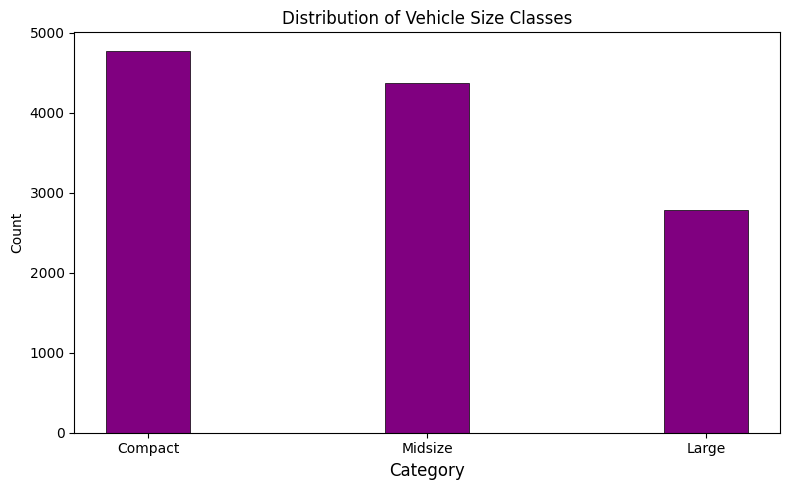

Imbalance ratio: 1.72:1


In [3]:
counts = df["Vehicle Size"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, width=0.3, color='purple', edgecolor='black', linewidth=0.5)

plt.title("Distribution of Vehicle Size Classes", fontsize=12)
plt.xlabel("Category", fontsize = 12)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Imbalance Ratio
ratio = counts.max() / counts.min()
print(f"Imbalance ratio: {ratio:.2f}:1")

## Class Balance Check

The classification target **Vehicle Size** has the following class distribution:
- **Compact:** 4,764 vehicles (40.0%)
- **Midsize:** 4,028 vehicles (33.8%)
- **Large:** 3,122 vehicles (26.2%)

The imbalance ratio (majority ÷ minority) = **1.72:1**, which is well below the 
5:1 threshold. Therefore, the dataset is **sufficiently balanced** and no special 
handling (such as oversampling or undersampling) is required during model evaluation 
in Phase 7.

# Phase 2: Exploratory Data Analysis

## 2.1 Univariate Distributions

### Theory
Skewness measures the asymmetry of a distribution around its mean:

$$\gamma_1 = \frac{E\left[(X - \mu)^3\right]}{\sigma^3}$$

- $\gamma_1 > 1$ → Right-skewed (long tail on right)
- $\gamma_1 < -1$ → Left-skewed (long tail on left)
- $\gamma_1 \approx 0$ → Symmetric

Kurtosis measures how heavy the tails are compared to a normal distribution:

$$\gamma_2 = \frac{E\left[(X - \mu)^4\right]}{\sigma^4} - 3$$

- $\gamma_2 > 1$ → Heavy tails (more extreme outliers)
- $\gamma_2 < -1$ → Light tails (fewer extreme outliers)
- $\gamma_2 \approx 0$ → Normal tails

This cell plots a histogram with KDE overlay for every numerical 
feature and computes skewness and kurtosis values.

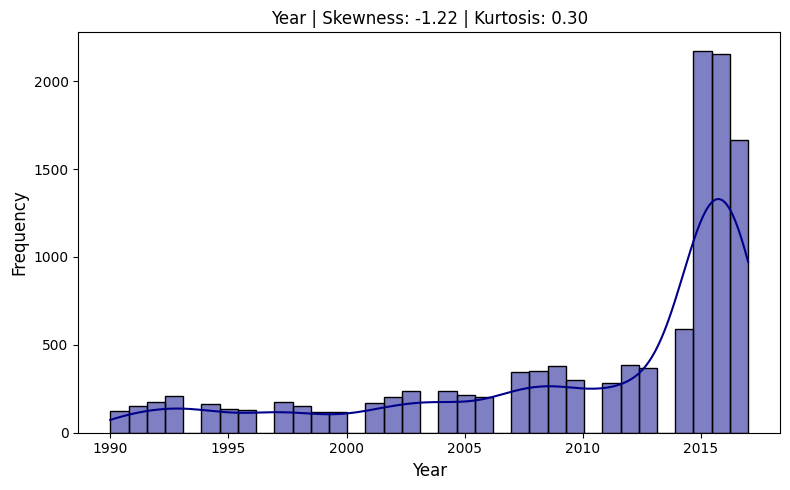

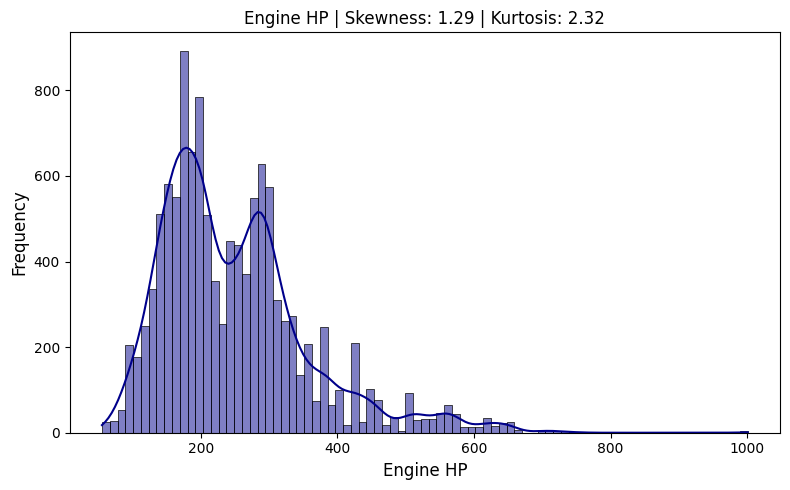

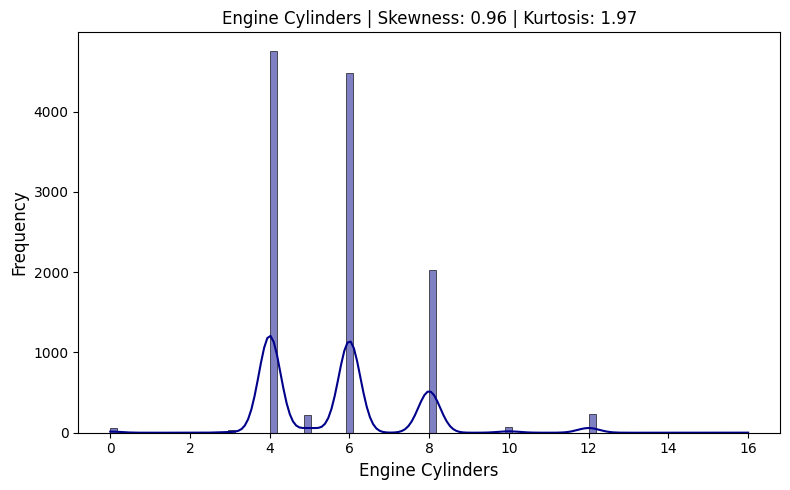

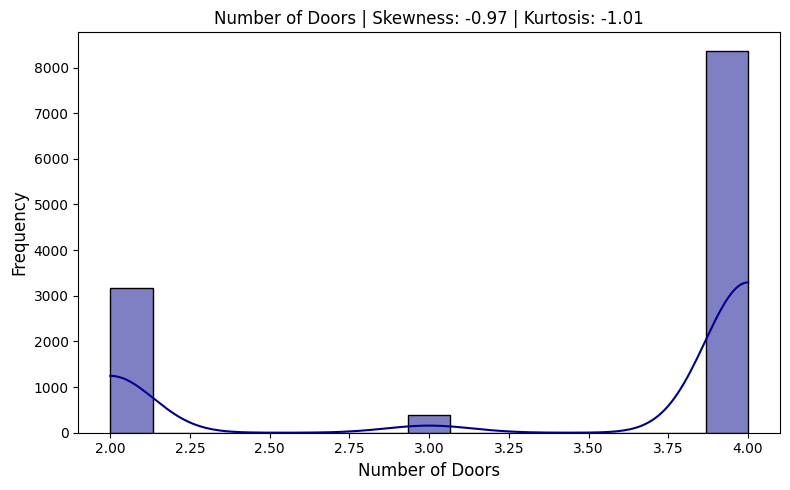

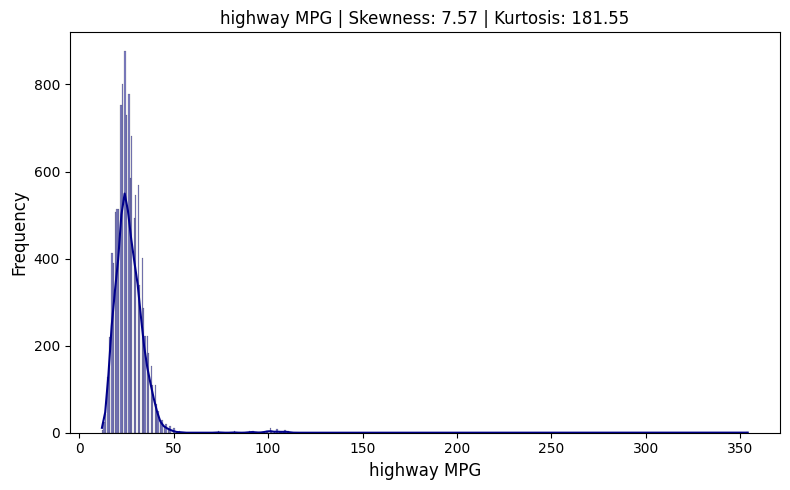

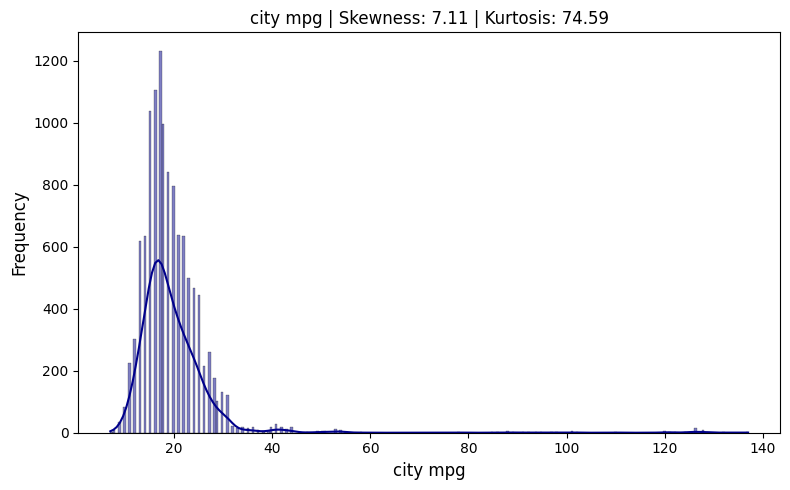

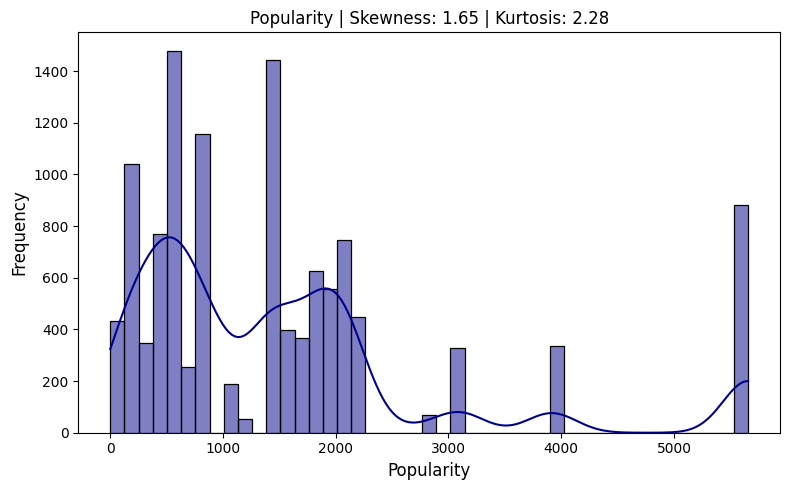

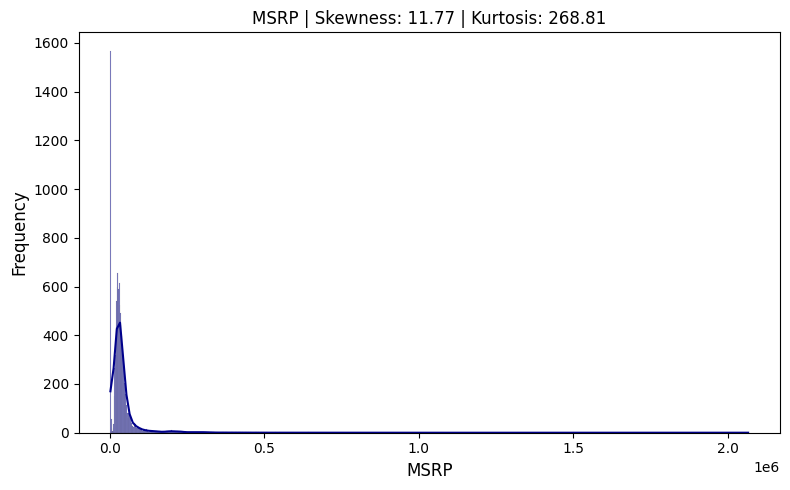

In [4]:


num_cols = df.select_dtypes(include='number').columns # Gets all numerical columns automatically

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True, color='darkblue') # drop.na() drops missing values
    
    skewness = stats.skew(df[col].dropna())
    kurtosis = stats.kurtosis(df[col].dropna())
    
    plt.title(f"{col} | Skewness: {skewness:.2f} | Kurtosis: {kurtosis:.2f}", fontsize=12)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.tight_layout()
    plt.show()

## Observations from Univariate Distributions

| Feature | Skewness (γ1) | Kurtosis (γ2) | Distribution Shape |
|---|---|---|---|
| Year | -1.22 | 0.30 | Left-skewed — more recent model years dominate |
| Engine HP | 1.29 | 2.32 | Right-skewed — few high-performance cars pull mean up |
| Engine Cylinders | 0.96 | 1.97 | Slightly right-skewed — most cars have 4-6 cylinders |
| Number of Doors | -0.97 | -1.01 | Slightly left-skewed, light tails — most cars have 4 doors |
| highway MPG | 7.57 | 181.55 | Severely right-skewed, extremely heavy tails — a few hybrid/electric vehicles with implausibly high MPG values |
| city mpg | 7.11 | 74.59 | Severely right-skewed, very heavy tails — same issue as highway MPG |
| Popularity | 1.65 | 2.28 | Right-skewed — few brands dominate Twitter mentions |
| MSRP | 11.77 | 268.81 | Most severely skewed — exotic cars worth millions create extreme right tail |

### Key Takeaways
- **MSRP, highway MPG, and city mpg** are severely right-skewed (γ1 > 1) 
and will require **log transformation** before regression modelling to reduce 
the influence of extreme values.
- **highway MPG (γ2 = 181.55) and MSRP (γ2 = 268.81)** have extremely heavy 
tails indicating dangerous outliers that must be treated in Phase 3.
- **Number of Doors** has light tails (γ2 = -1.01) — values are tightly 
clustered around 2 and 4 with almost no variation.
- **Year** is left-skewed (γ1 = -1.22) — the dataset is heavily biased 
toward recent model years (2010–2017).

## 2.2 Categorical Analysis

This cell plots a bar chart of value counts for every categorical 
feature sorted by frequency, and identifies rare categories 
comprising less than 1% of the data (< 119 rows).

**Note:** The Model column (915 unique values) is excluded from 
visualization as it is essentially an ID column and is not suitable 
for bar chart analysis. It will be dropped during Phase 3 preprocessing.

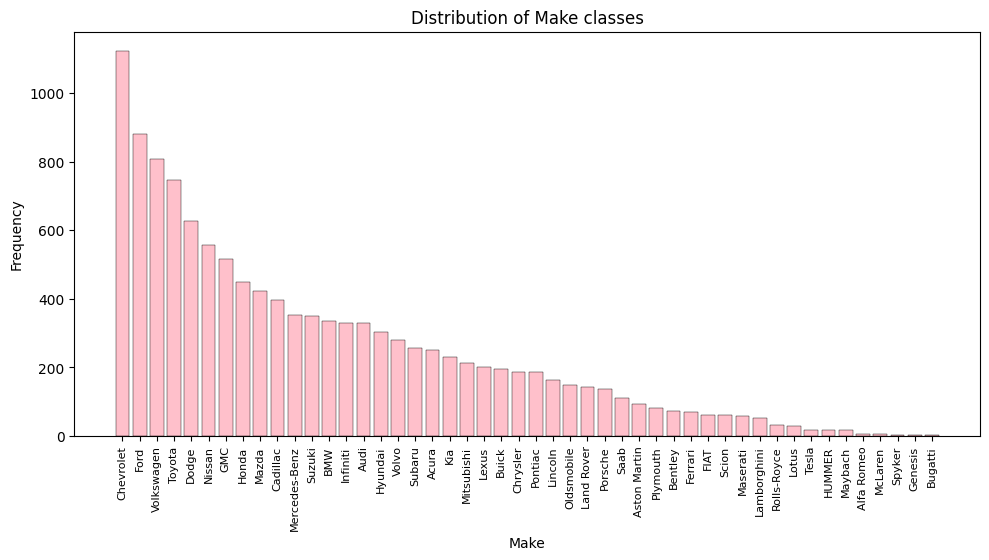


Rare categories in Make (< 1%):
Make
Saab            111
Aston Martin     93
Plymouth         82
Bentley          74
Ferrari          69
FIAT             62
Scion            60
Maserati         58
Lamborghini      52
Rolls-Royce      31
Lotus            29
Tesla            18
HUMMER           17
Maybach          16
Alfa Romeo        5
McLaren           5
Spyker            3
Genesis           3
Bugatti           3
Name: count, dtype: int64


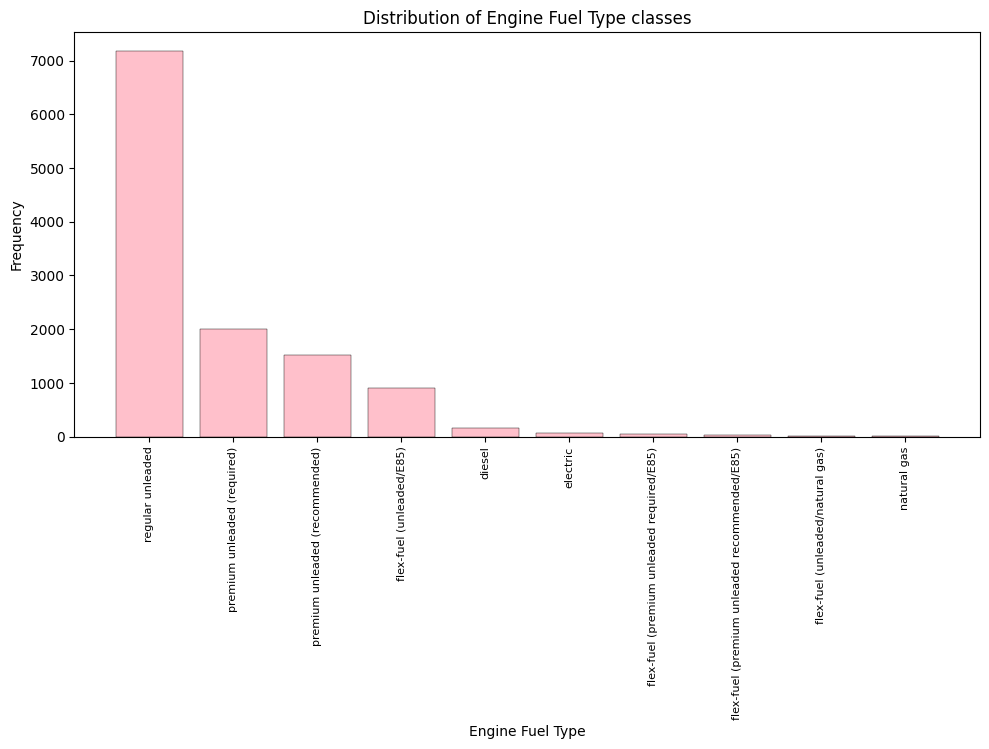


Rare categories in Engine Fuel Type (< 1%):
Engine Fuel Type
electric                                        66
flex-fuel (premium unleaded required/E85)       54
flex-fuel (premium unleaded recommended/E85)    26
flex-fuel (unleaded/natural gas)                 6
natural gas                                      2
Name: count, dtype: int64


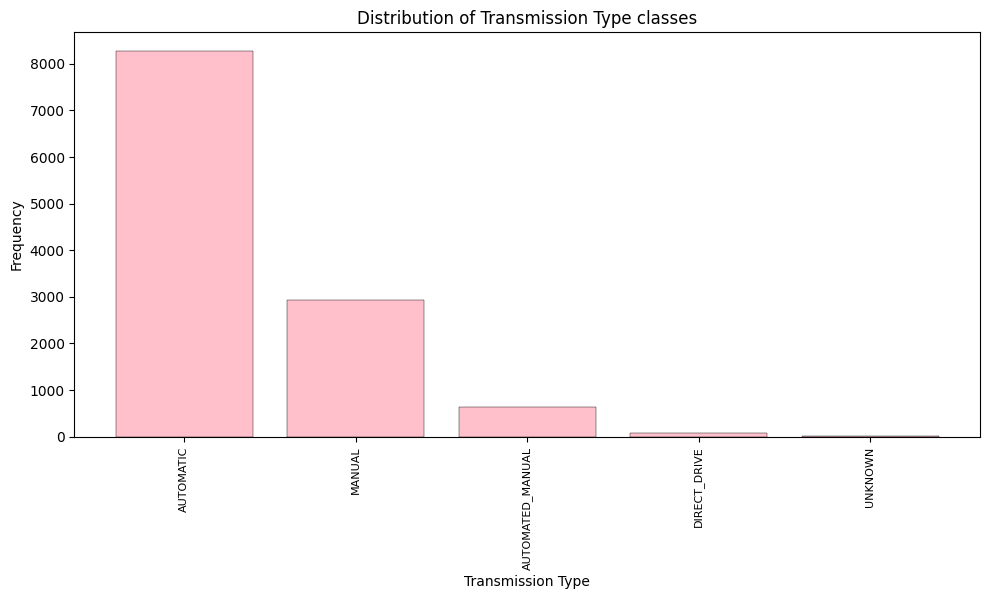


Rare categories in Transmission Type (< 1%):
Transmission Type
DIRECT_DRIVE    68
UNKNOWN         19
Name: count, dtype: int64


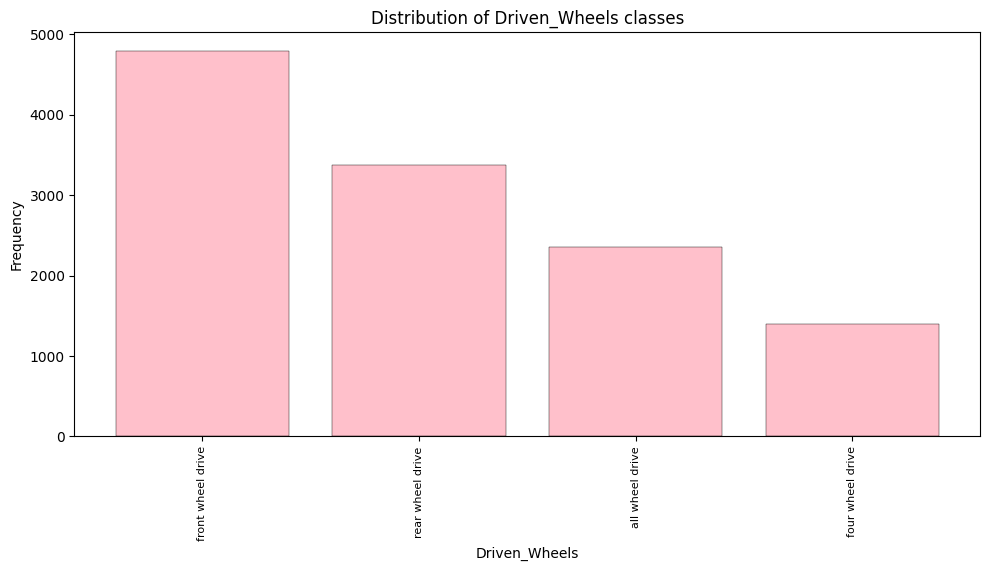

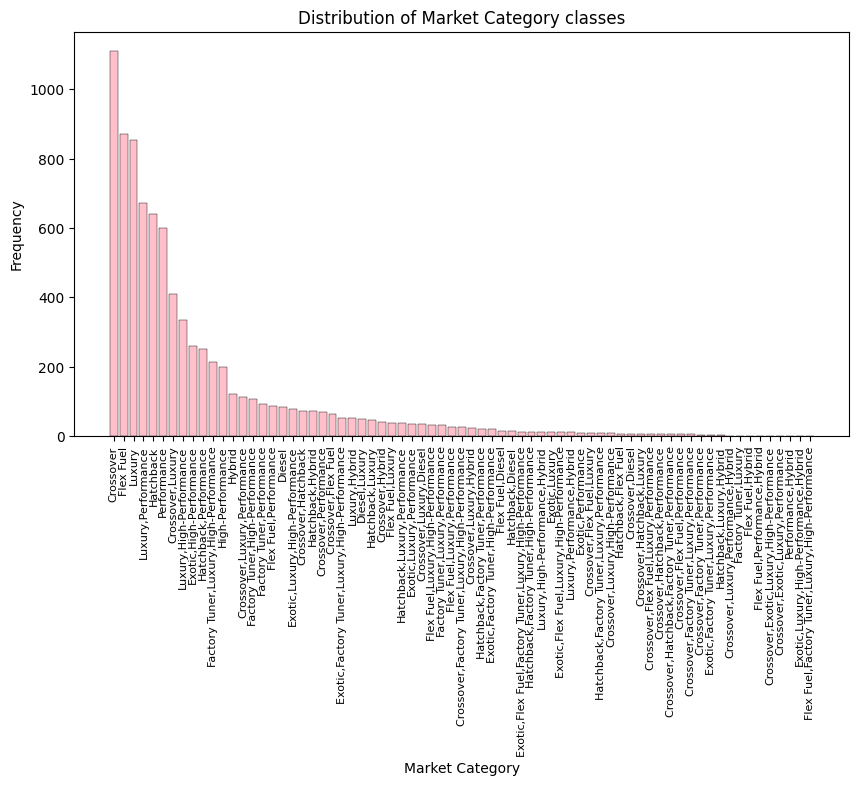


Rare categories in Market Category (< 1%):
Market Category
Crossover,Luxury,Performance                              113
Factory Tuner,High-Performance                            106
Factory Tuner,Performance                                  92
Flex Fuel,Performance                                      87
Diesel                                                     84
Exotic,Luxury,High-Performance                             79
Crossover,Hatchback                                        72
Hatchback,Hybrid                                           72
Crossover,Performance                                      69
Crossover,Flex Fuel                                        64
Exotic,Factory Tuner,Luxury,High-Performance               52
Luxury,Hybrid                                              52
Diesel,Luxury                                              51
Hatchback,Luxury                                           46
Crossover,Hybrid                                           42
Flex Fuel,

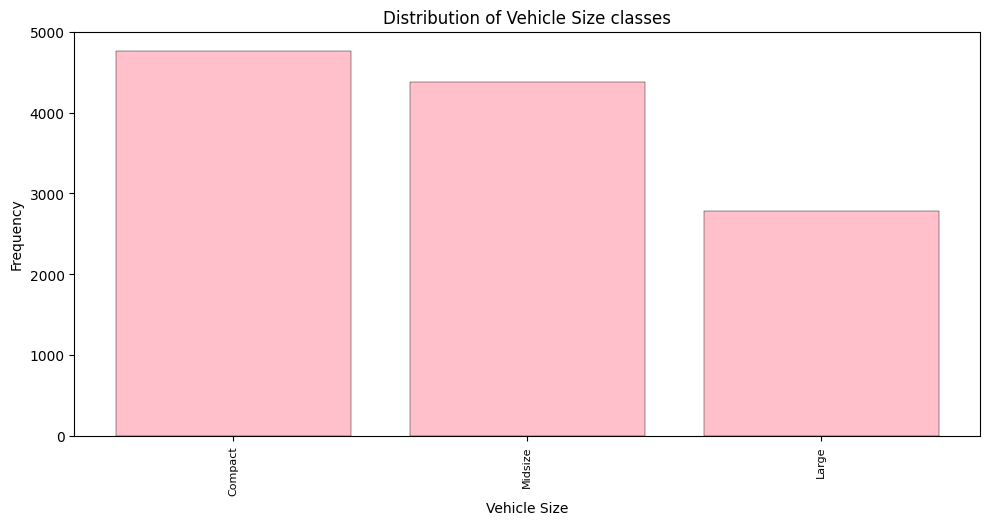

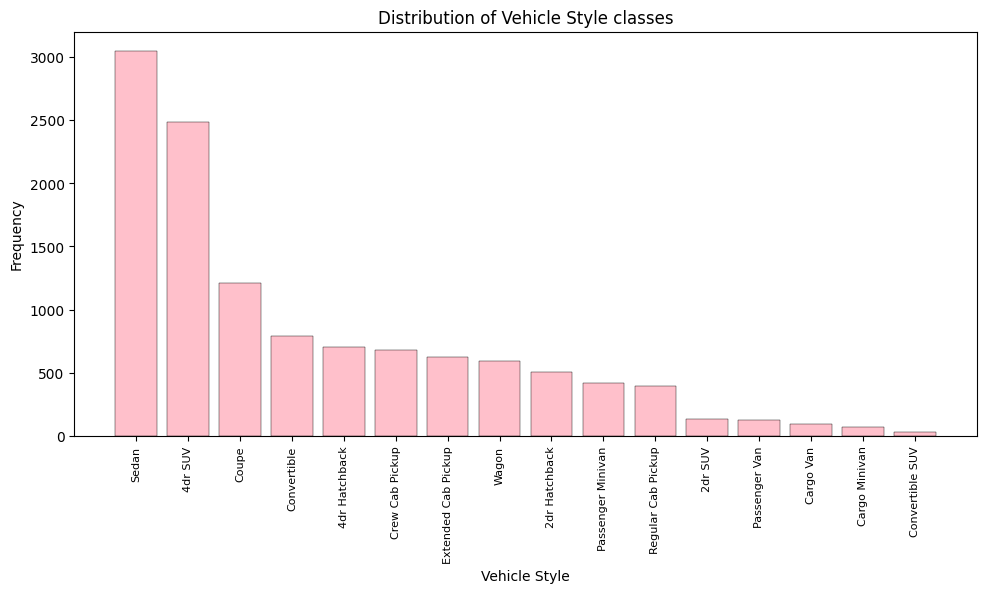


Rare categories in Vehicle Style (< 1%):
Vehicle Style
Cargo Van          95
Cargo Minivan      71
Convertible SUV    29
Name: count, dtype: int64


In [5]:
cat_cols = df.select_dtypes(include='object').columns # Gets all categorical columns automatically
# columns to skip — too many unique values
skip_cols = ['Model']

for col in cat_cols:
    if col in skip_cols:
        continue          # skip this column entirely
    
    plt.figure(figsize=(10, 5))
   
    counts = df[col].value_counts()
    
    bars = plt.bar(counts.index, counts.values, color = 'pink', edgecolor = 'black', linewidth = 0.3)
    plt.title(f"Distribution of {col} classes", fontsize = 12)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.xticks(rotation=90, fontsize=8) # It rotates x-axis labels 90 degrees vertically and makes them smaller so they don't overlap each other
    plt.show()
    
    # Display the rare categories
    rare = counts[counts < 119]
    if len(rare) > 0:
        print(f"\nRare categories in {col} (< 1%):")
        print(rare)

## Observations from Categorical Analysis

### Rare Categories Identified (< 1% of data = < 119 rows)

| Column | Rare Categories | Action in Phase 3 |
|---|---|---|
| **Make** | Saab, Aston Martin, Plymouth, Bentley, Ferrari, FIAT, Scion, Maserati, Lamborghini, Rolls-Royce, Lotus, Tesla, Spyker, Genesis, Bugatti | Group into "Other" category |
| **Engine Fuel Type** | electric, flex-fuel variants, natural gas | Group into "Other" category |
| **Transmission Type** | DIRECT_DRIVE, UNKNOWN | Group into "Other" or drop |
| **Market Category** | 40+ rare combinations | Drop column — too many unique combinations |
| **Vehicle Style** | Cargo Van, Cargo Minivan, Convertible SUV | Group into "Other" category |

### Key Observations

- **Make** is heavily dominated by Chevrolet (1,123 cars) — 15 out of 48 
brands are rare and will need grouping.
- **Engine Fuel Type** is dominated by regular unleaded (7,172 cars = 60%) — 
5 fuel types are rare including electric vehicles.
- **Transmission Type** is dominated by AUTOMATIC (8,266 cars = 69%) — 
DIRECT_DRIVE and UNKNOWN are rare and will be grouped.
- **Market Category** has 71 unique combinations — extremely high cardinality. 
This column will be dropped in Phase 3 or frequency encoded.
- **Vehicle Size** is well balanced — Compact (4,764), Midsize (4,386), 
Large (2,764) — confirming our classification target is suitable.
- **Vehicle Style** has 3 rare body types that will be grouped into "Other" 
during Phase 3 encoding.
- **Driven Wheels** and **Vehicle Style** show no surprising distributions — 
front wheel drive dominates as expected for a US market dataset.

## 2.3 Correlation Matrix

This cell computes the Pearson correlation matrix for all numerical 
features and visualizes it as an annotated heatmap.

### Pearson Correlation Formula
The Pearson correlation coefficient between two variables x and y:

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

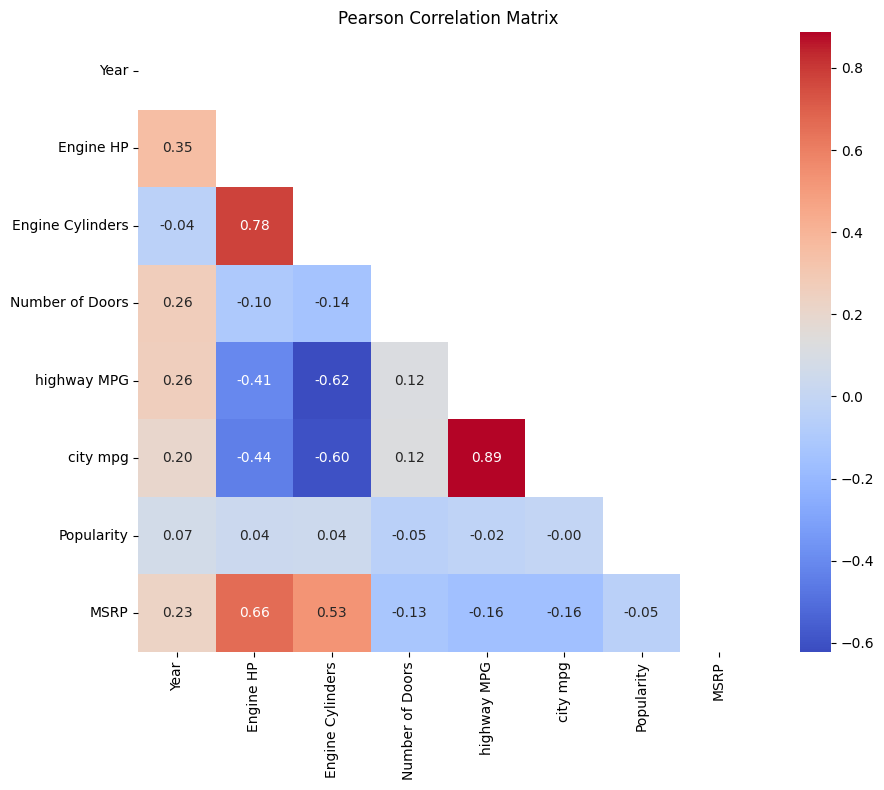

In [6]:
# select all numerical columns at once
corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr)) # Mask hides the upper triangle of the correlation matrix to avoid showing the same correlation value twice

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, 
            cmap="coolwarm", fmt=".2f", square=True)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# Cool = blue = negative correlation
# Warm = red = positive correlation
# White = zero correlation = middle

## Observations from Correlation Matrix

### Top 3 Positive Correlations with MSRP
| Feature | Correlation with MSRP | Interpretation |
|---|---|---|
| Engine HP | 0.66 | Strong positive — more powerful engines cost more |
| Engine Cylinders | 0.53 | Moderate positive — more cylinders means higher price |
| Year | 0.23 | Weak positive — newer models tend to cost more |

### Top 3 Negative Correlations with MSRP
| Feature | Correlation with MSRP | Interpretation |
|---|---|---|
| city mpg | -0.16 | Weak negative — fuel efficient cars tend to be cheaper |
| highway MPG | -0.16 | Weak negative — same pattern as city mpg |
| Number of Doors | -0.13 | Weak negative — more doors slightly associated with lower price |

### Multicollinearity Warning — |r| > 0.8
| Feature Pair | Correlation | Action |
|---|---|---|
| highway MPG vs city mpg | **0.89** | Strong multicollinearity — these two features are nearly identical. One may need to be dropped in Phase 5 to avoid destabilising regression coefficients |
| Engine HP vs Engine Cylinders | **0.78** | Approaching multicollinearity threshold — monitor carefully |

### Key Takeaway
Engine HP is the strongest predictor of MSRP (r = 0.66), confirming 
that more powerful cars are significantly more expensive. The near-perfect 
correlation between highway MPG and city mpg (r = 0.89) indicates 
redundant features that will be addressed during feature selection in Phase 5.

## 2.4 Bivariate Plots

This section produces three types of bivariate plots: scatter plots of top 5 
features vs MSRP with trend lines, box plots of numerical features grouped by 
Vehicle Size, and a pair plot of top 5 features coloured by Vehicle Size.

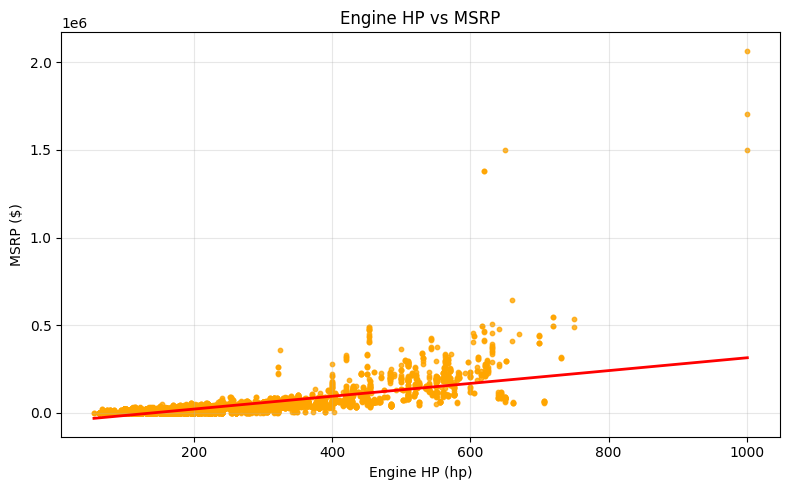

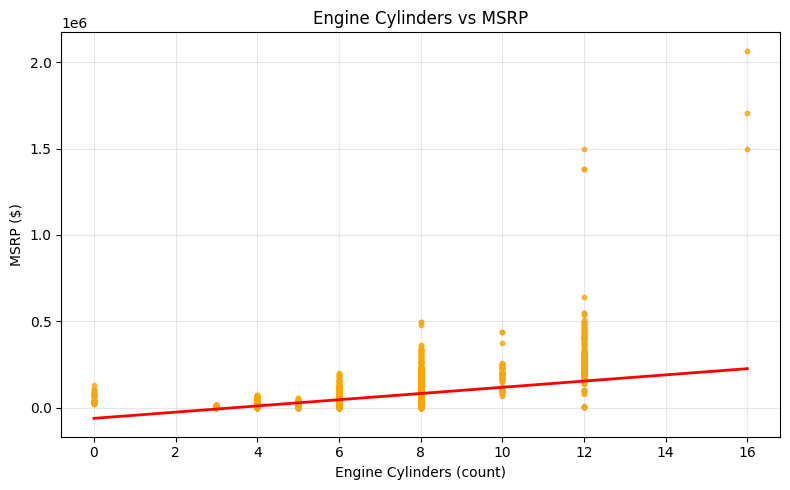

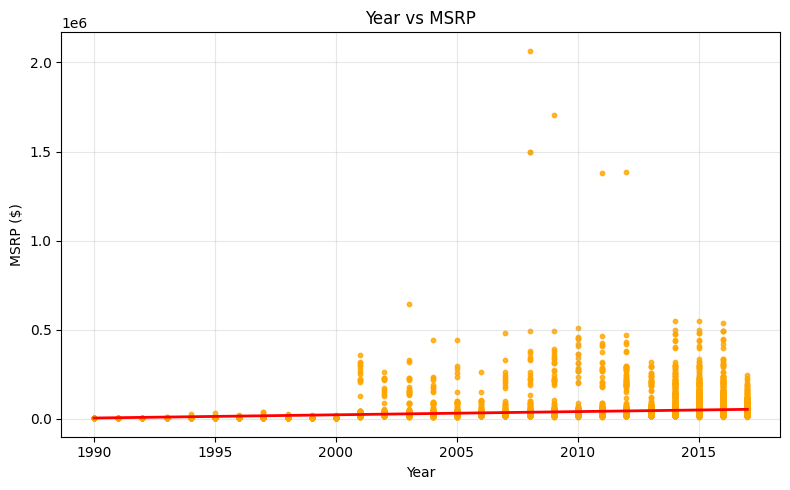

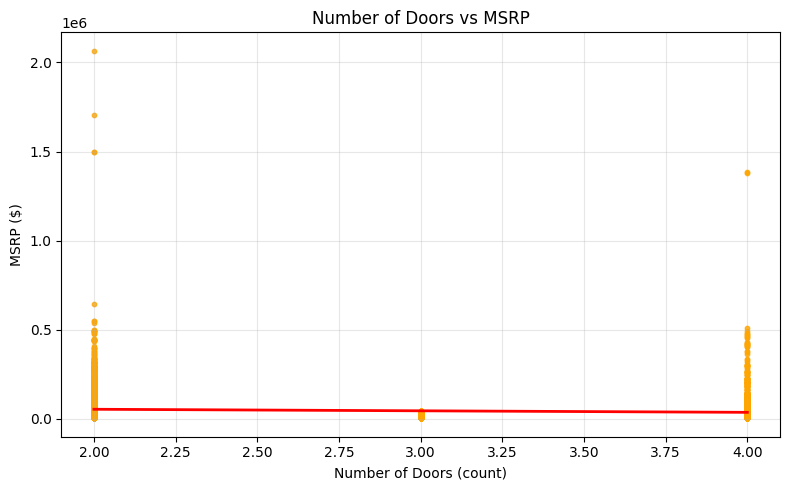

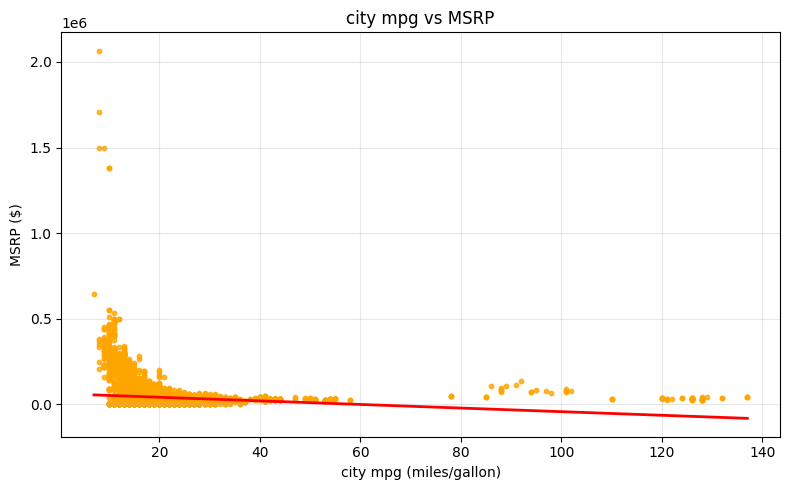

In [7]:
# Based on their correlation

top5_features= {
    'Engine HP': 'Engine HP (hp)',
    'Engine Cylinders': 'Engine Cylinders (count)',
    'Year': 'Year',
    'Number of Doors': 'Number of Doors (count)',
    'city mpg': 'city mpg (miles/gallon)'
}

for feature in top5_features:
    temp = df[[feature, 'MSRP']].dropna()  # drop missing from both together to make them equally sized
    
    plt.figure(figsize=(8, 5))
    plt.scatter(temp[feature], temp["MSRP"], 
                color='orange',
                alpha=0.8,
                s=10)
    
    # Trend line
    coeffs = np.polyfit(temp[feature], temp['MSRP'], deg=1)
    trend = np.poly1d(coeffs)
    x_sorted = np.sort(temp[feature])
    plt.plot(x_sorted, trend(x_sorted), color='red', linewidth=2)
    
    plt.title(f"{feature} vs MSRP")
    plt.xlabel(top5_features[feature])
    plt.ylabel("MSRP ($)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show() 

### Observations from Scatter Plots

| Feature | Trend | Interpretation |
|---|---|---|
| Engine HP vs MSRP | ↗ Positive | Strong upward trend confirms r = 0.66 — more powerful engines cost significantly more |
| Engine Cylinders vs MSRP | ↗ Positive | Upward trend confirms r = 0.53 — more cylinders associated with higher price |
| Year vs MSRP | ↗ Weak positive | Slight upward trend confirms r = 0.23 — newer models tend to cost more |
| Number of Doors vs MSRP | → Flat | Almost no trend confirms r = -0.13 — number of doors has negligible effect on price |
| city mpg vs MSRP | ↘ Negative | Downward trend confirms r = -0.16 — fuel efficient cars tend to be cheaper |

**Outlier Note:** Extreme MSRP outliers (exotic cars > $500,000 such as Bugatti 
and Lamborghini) are visible in all scatter plots as isolated dots at the top. 
These pull the trend lines upward making them less representative of the majority 
of cars. These outliers will be treated during Phase 3 using IQR method before 
regression modelling in Phase 6.

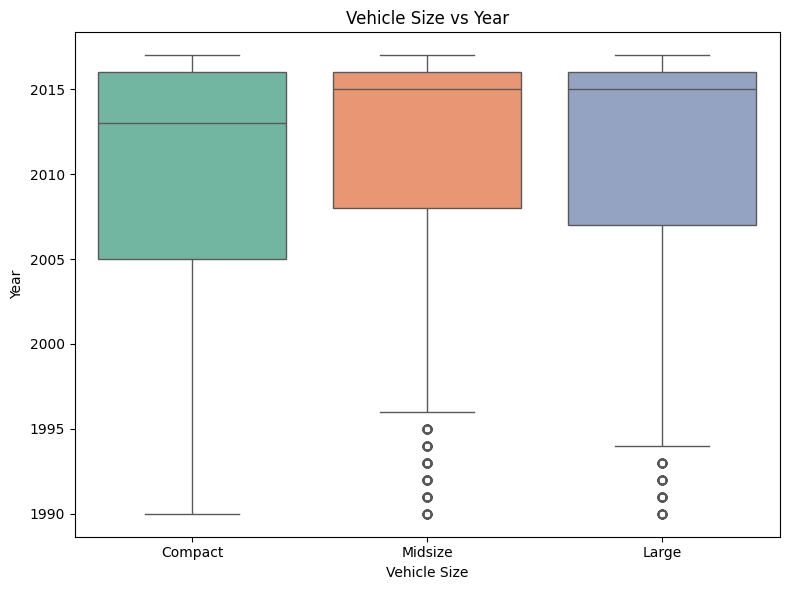

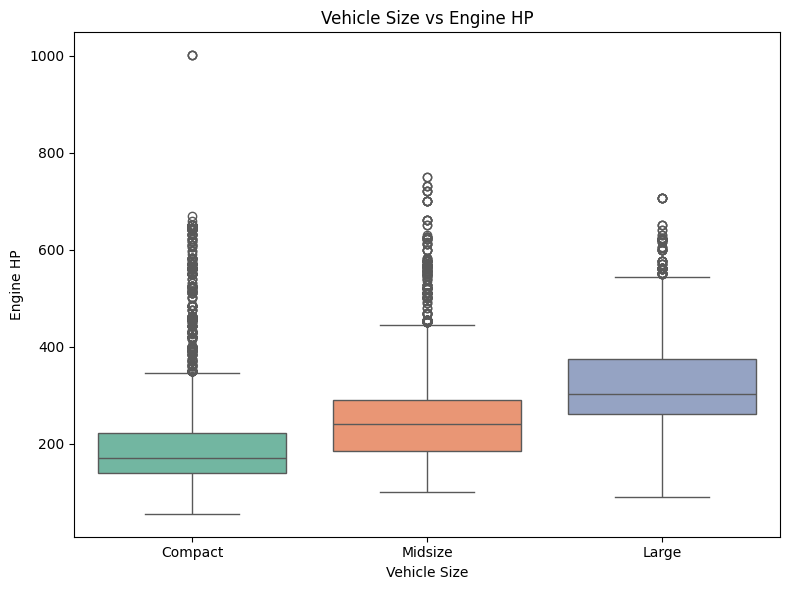

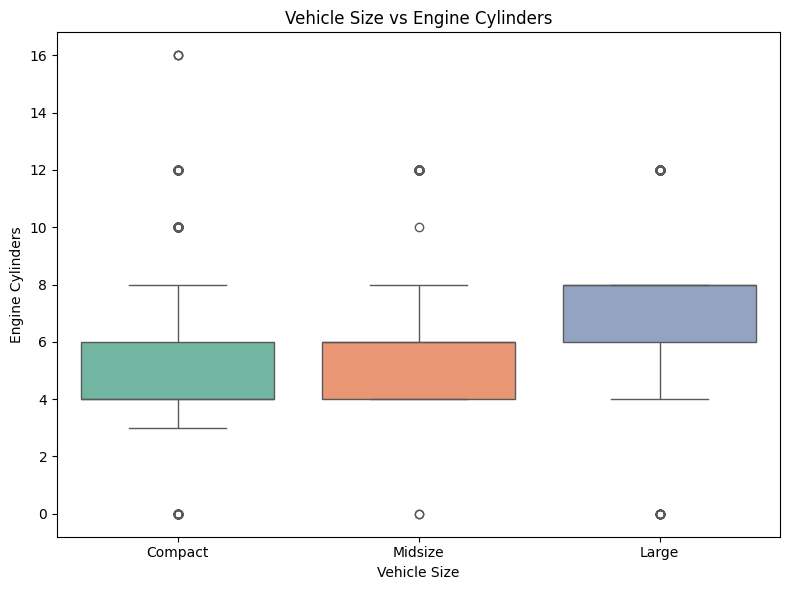

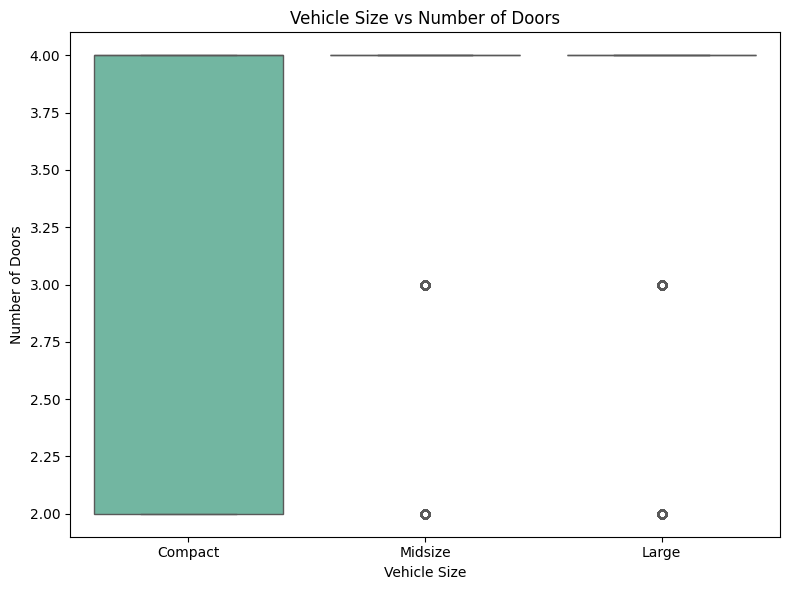

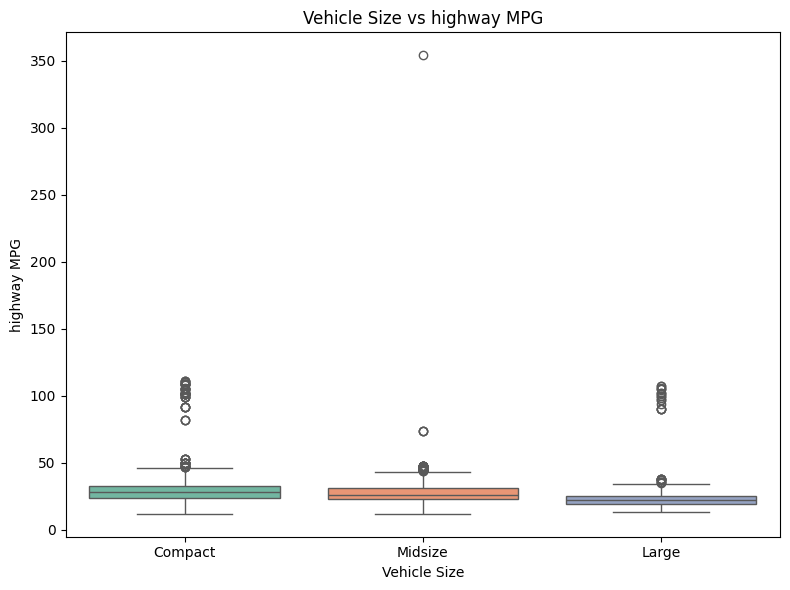

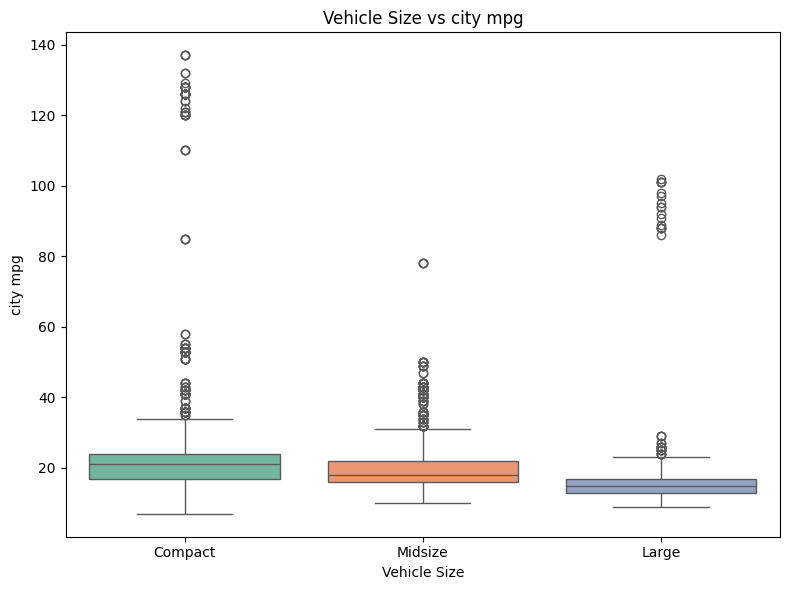

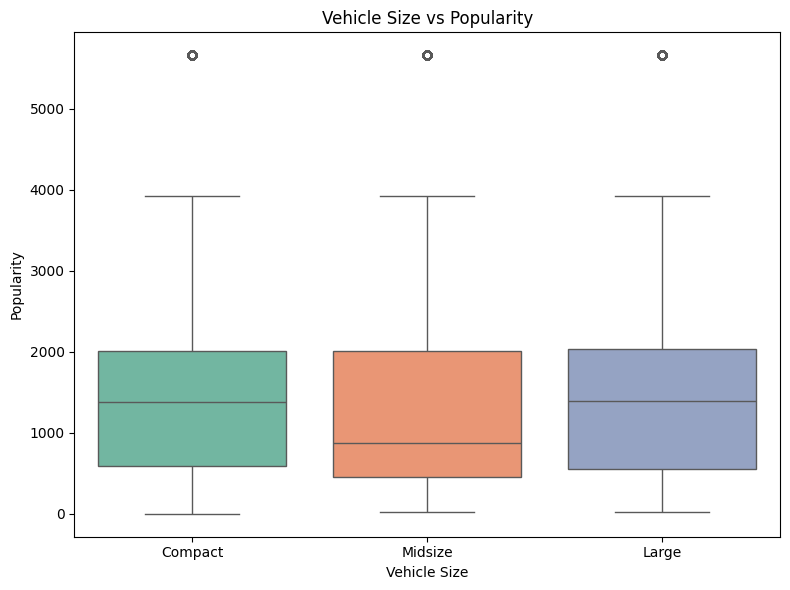

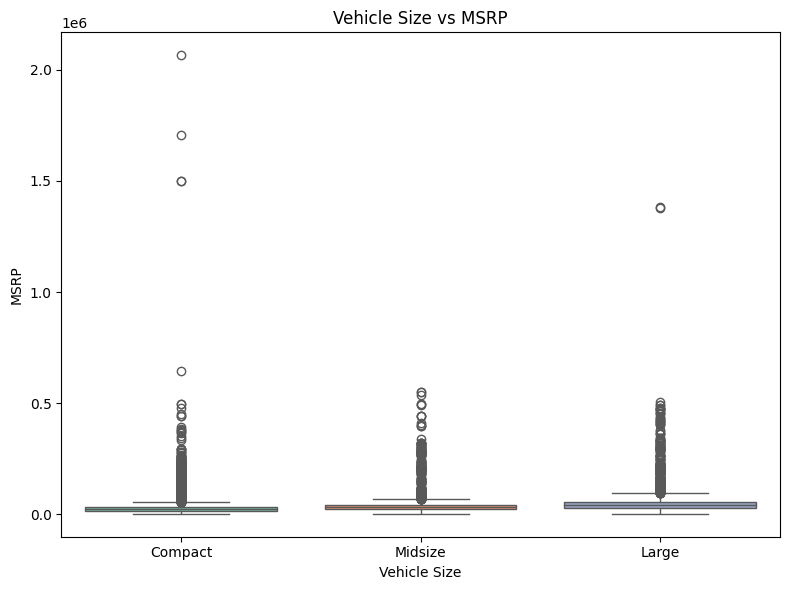

In [8]:
num_cols = df.select_dtypes(include="number").columns

for feature in num_cols:
    
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Vehicle Size', y=feature, data=df, 
            hue='Vehicle Size', palette='Set2', legend=False)
    
    plt.title(f"Vehicle Size vs {feature}")
    plt.xlabel("Vehicle Size")
    plt.ylabel(feature)
    
    plt.tight_layout()

## Observations from Box Plots

| Feature | Separation Between Classes | Useful for Classification? |
|---|---|---|
| Engine HP |  Clear — Large cars have highest HP (median ~300), Compact lowest (~180) |  Yes |
| Engine Cylinders |  Clear — Large cars have more cylinders (median ~7), Compact fewer (~5) |  Yes |
| highway MPG |  Moderate — Compact cars are more fuel efficient than Large |  Yes |
| city mpg |  Moderate — Compact slightly higher mpg than Large |  Yes |
| Year |  Poor — all three classes have similar year distributions |  No |
| Number of Doors |  Poor — almost no variation across classes |  No |
| Popularity |  Poor — boxes heavily overlap across all three classes |  No |
| MSRP |  Poor — extreme outliers dominate, boxes too compressed to compare |  No |

### Key Takeaway
**Engine HP and Engine Cylinders** show the clearest separation between 
Compact, Midsize and Large vehicles — these will likely be the most 
important features for the classification model in Phase 7. 
**Year, Number of Doors, and Popularity** show almost no separation 
between classes and may not contribute meaningfully to classification.

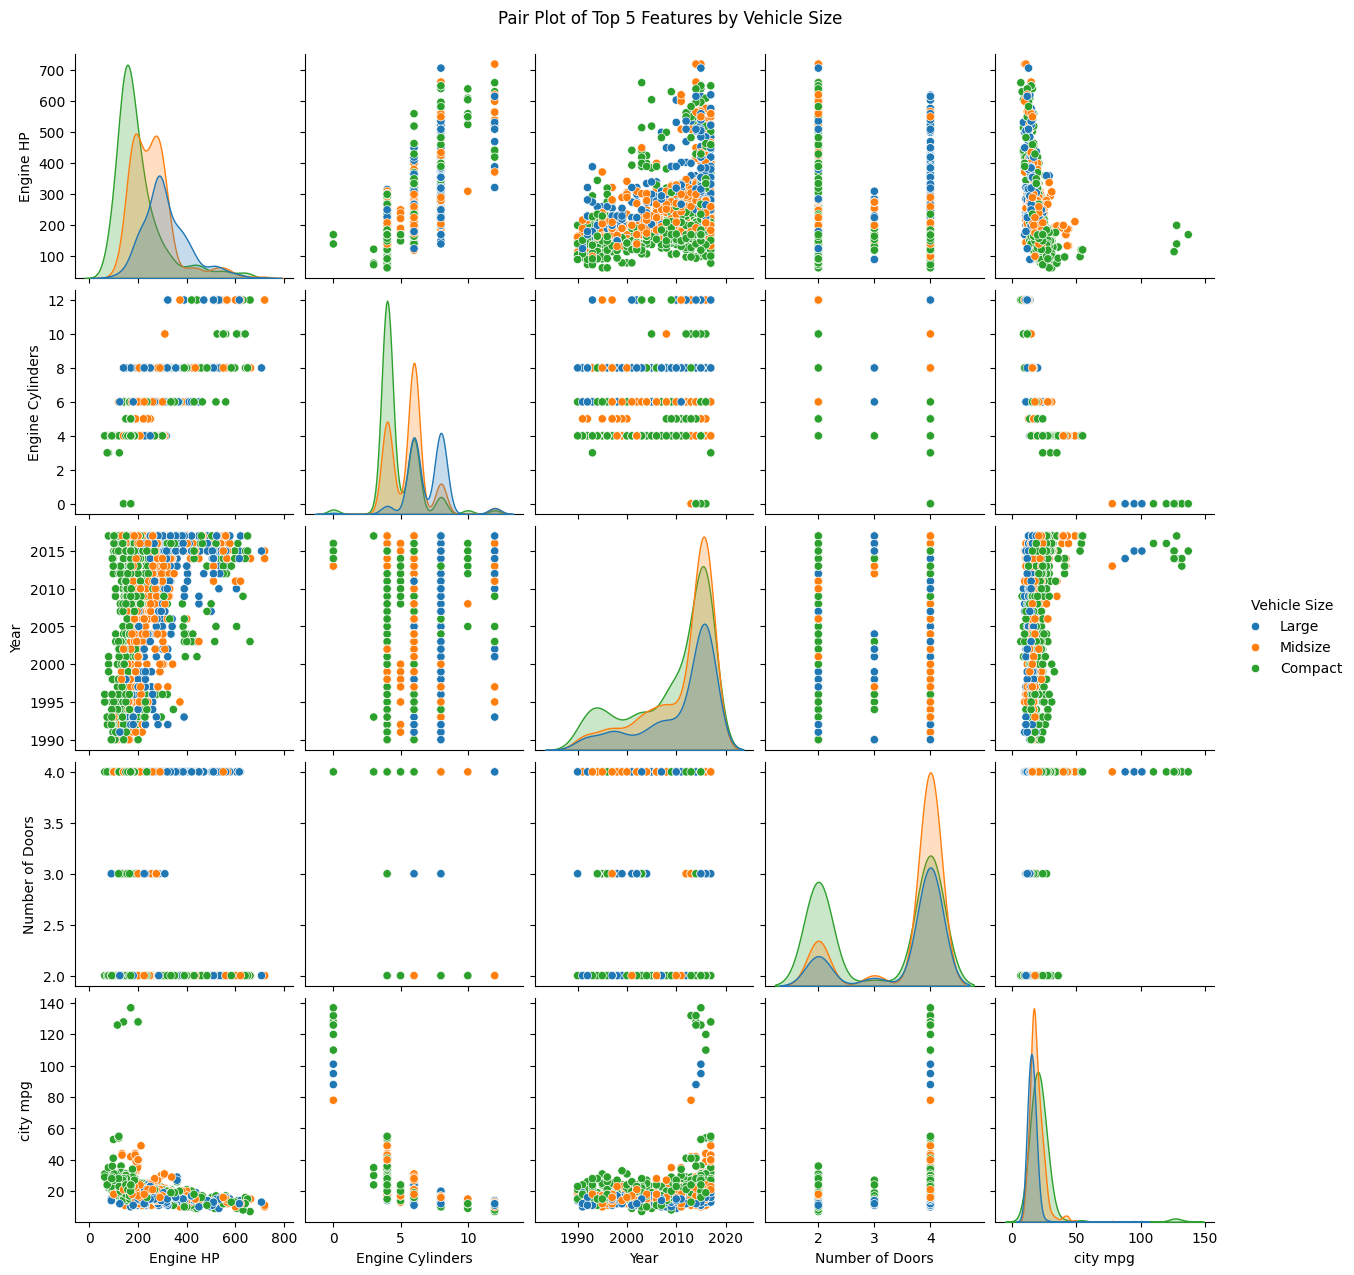

In [9]:
df_sample = df.sample(2000, random_state=42)

# Pair plot = a grid of plots that shows which features can differentiate classification target classes — both individually (diagonal)
# and in combination (off-diagonal).    
sns.pairplot(df_sample, vars=list(top5_features.keys()), hue='Vehicle Size')
plt.suptitle("Pair Plot of Top 5 Features by Vehicle Size", 
             y=1.02, fontsize=12)

plt.show()

### Pair Plot — Top 5 Features by Vehicle Size

The pair plot reveals that **Engine HP and Engine Cylinders** are the strongest 
individual features for separating Vehicle Size classes — their diagonal KDE 
plots show three distinct peaks for Compact, Midsize and Large. Together, 
Engine HP and Engine Cylinders show clear color clustering in their scatter 
plot with Large cars (blue) concentrated at high HP and high cylinder values 
while Compact cars (green) cluster at lower values. In contrast, **Year and 
Number of Doors** show completely mixed colors in all scatter plots indicating 
they cannot distinguish between vehicle sizes. These findings will directly 
guide feature selection in Phase 5 and model building in Phase 7.

## 2.5 Temporal or spatial patterns

This section substitutes the temporal/spatial plot since the dataset contains 
no timestamp or location column. Instead, violin plots of the two most 
interesting features (Engine HP and MSRP) are produced, stratified by 
Vehicle Size classification target.

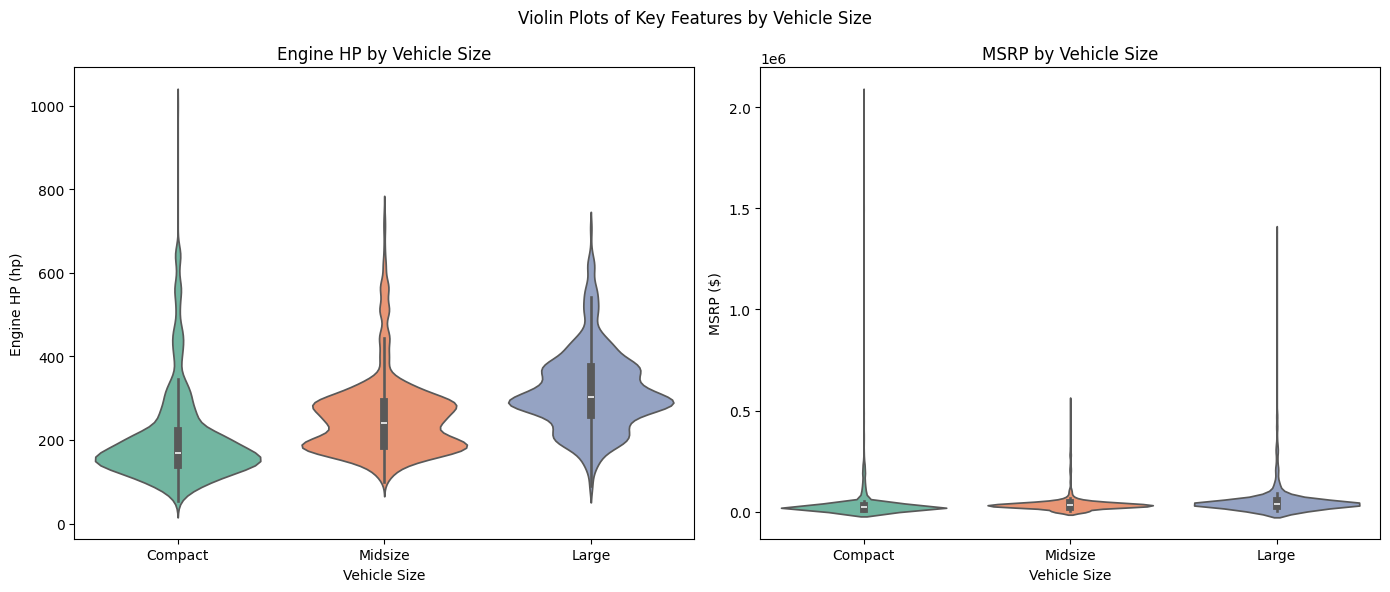

In [10]:
# Two most interesting features stratified by Vehicle Size:

# Engine HP — most correlated with MSRP
# MSRP — our regression target 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Engine HP by Vehicle Size
sns.violinplot(x='Vehicle Size', y='Engine HP', 
               data=df, hue='Vehicle Size',
               palette='Set2', legend=False, ax=axes[0])
axes[0].set_title("Engine HP by Vehicle Size")
axes[0].set_xlabel("Vehicle Size")
axes[0].set_ylabel("Engine HP (hp)")

# Plot 2 — MSRP by Vehicle Size
sns.violinplot(x='Vehicle Size', y='MSRP', 
               data=df, hue='Vehicle Size',
               palette='Set2', legend=False, ax=axes[1])
axes[1].set_title("MSRP by Vehicle Size")
axes[1].set_xlabel("Vehicle Size")
axes[1].set_ylabel("MSRP ($)")

plt.suptitle("Violin Plots of Key Features by Vehicle Size", fontsize=12)
plt.tight_layout()
plt.show()

## Observations from Violin Plots

**Engine HP violin plot** shows three clearly separated distributions — 
Compact cars are widest around 150–200 HP, Midsize around 200–250 HP, 
and Large around 300 HP with three distinct medians. This confirms that 
Engine HP is a strong differentiator between vehicle size classes.

**MSRP violin plot** shows three violins with almost identical medians 
compressed at the bottom — all three classes have similar price distributions 
with extreme outliers stretching upward. This confirms that MSRP alone 
cannot effectively differentiate between vehicle size classes and is heavily 
influenced by exotic car outliers that will be treated in Phase 3.

**Key Takeaway:** Vehicle Size is best differentiated by Engine HP rather 
than MSRP — Engine HP produces three clearly distinct medians across classes 
while MSRP medians are almost identical across all three vehicle sizes.

## 2.6 EDA Summary Narrative

Exploratory data analysis of the automotive dataset revealed five critical 
findings that will directly inform modelling decisions in later phases.

**Finding 1 — Severe Right Skewness in Key Features:**
MSRP (γ1 = 11.77), highway MPG (γ1 = 7.57), and city mpg (γ1 = 7.11) 
are severely right-skewed, indicating that a small number of extreme values 
— such as exotic cars and electric vehicles — dominate these distributions. 
Log transformation will be applied to MSRP before regression modelling.

**Finding 2 — Extreme Heavy Tails Indicating Dangerous Outliers:**
MSRP (γ2 = 268.81) and highway MPG (γ2 = 181.55) show extremely heavy 
tails confirming the presence of dangerous outliers. In contrast, Number 
of Doors (γ2 = -1.01) has light tails with values tightly clustered 
around 2 and 4. These outliers will be treated using IQR method in Phase 3.

**Finding 3 — Strong Correlations with MSRP:**
Engine HP (r = 0.66) and Engine Cylinders (r = 0.53) show the strongest 
positive correlations with MSRP — more powerful engines with more cylinders 
are significantly more expensive. Highway MPG (r = -0.16) and city mpg 
(r = -0.16) show weak negative correlations — fuel efficient cars tend 
to be cheaper. A critical multicollinearity warning was identified between 
highway MPG and city mpg (r = 0.89) — these two features are nearly 
identical and one may need to be dropped in Phase 5.

**Finding 4 — Extreme MSRP Outliers Distorting Analysis:**
Exotic cars such as Bugatti and Lamborghini with MSRP > $500,000 appear 
as isolated dots in all scatter plots, pulling trend lines upward and 
making them less representative of the majority of cars priced between 
$20,000–$40,000. These outliers will be treated in Phase 3 using IQR 
method before regression modelling in Phase 6.

**Finding 5 — Engine HP Best Differentiates Vehicle Size Classes:**
Box plots and violin plots confirm that Engine HP produces three clearly 
distinct medians across vehicle size classes — Compact (~180 HP), 
Midsize (~240 HP), and Large (~300 HP). In contrast, Year, Number of 
Doors, and Popularity show almost no separation between classes and will 
likely contribute minimally to the classification model in Phase 7. 
Pair plot analysis further confirms that Engine HP and Engine Cylinders 
together provide the strongest visual separation between Compact, 
Midsize and Large vehicles.

# Phase 3: Data Cleaning & Preprocessing

In [11]:
# Reload fresh copy of dataset for Phase 3
df = pd.read_csv("data.csv")

## 3.1 Missing Value Audit

This cell computes missing value counts and percentages per column 
and visualizes them as a bar chart with a 40% drop threshold line.

                  Missing Count  Missing Percent
Market Category            3742        31.408427
Engine HP                    69         0.579151
Engine Cylinders             30         0.251805
Number of Doors               6         0.050361
Engine Fuel Type              3         0.025180


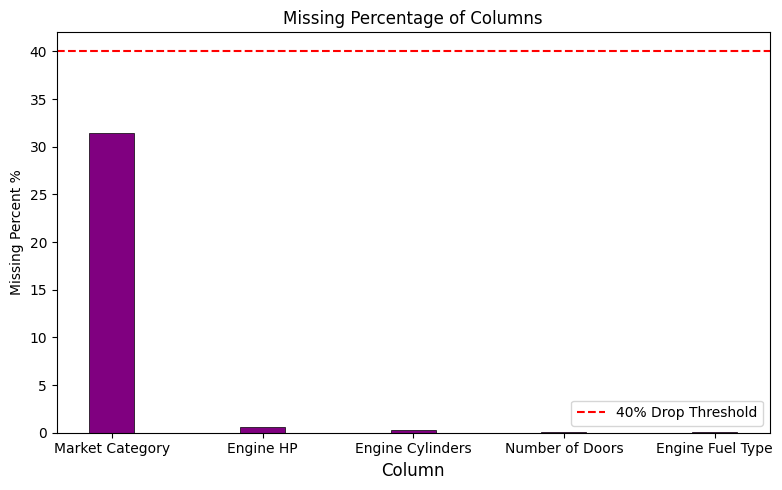

In [12]:
# Count missing values per column
missing_count = df.isnull().sum()
missing_percent = (missing_count/ len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent': missing_percent
})

# Keep only columns that have missing values, sorted by percentage
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percent', ascending=False)
print(missing_df)

plt.figure(figsize=(8, 5))
bars = plt.bar(missing_df.index, missing_df["Missing Percent"].values, width=0.3, color='purple', edgecolor='black', linewidth=0.5)
plt.title("Missing Percentage of Columns", fontsize=12)
plt.xlabel("Column", fontsize = 12)
plt.ylabel("Missing Percent %")

# Threshold Line
plt.axhline(y=40, color='red', linestyle='--', label='40% Drop Threshold')
plt.legend()
plt.tight_layout()
plt.show()

## Observations from Missing Value Audit

Market Category has the highest missing percentage at 31.4% — 
below the 40% drop threshold but will be dropped due to high 
cardinality (71 unique combinations) and multi-label format. 
All other columns have less than 1% missing values and will be 
treated with median or mode imputation.

## Missing Value Decision Table

| Column | Missing Count | Missing % | Strategy | Justification |
|---|---|---|---|---|
| Market Category | 3,742 | 31.4% | Drop column | Too many unique combinations (71) making imputation meaningless. Comma separated multiple values in one cell|
| Engine HP | 69 | 0.58% | Median imputation | Right-skewed distribution (γ1 = 1.29) — median is more robust than mean for skewed data |
| Engine Cylinders | 30 | 0.25% | Median imputation | Discrete numerical column — median imputation preserves typical cylinder counts |
| Number of Doors | 6 | 0.05% | Median imputation | Only 6 rows affected — median imputation with negligible impact |
| Engine Fuel Type | 3 | 0.03% | Mode imputation | Categorical column — replace with most frequent category (regular unleaded) |

In [13]:
# Median imputation
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())
df['Number of Doors'] = df['Number of Doors'].fillna(df['Number of Doors'].median())

# Mode imputation
df['Engine Fuel Type'] = df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0])

## 3.2 Outlier Detection and Treatment

This cell applies IQR fences to detect outliers in all numerical columns 
and treats them using Winsorisation, row dropping, or retention based 
on domain knowledge.

IQR Formula:
$$IQR = Q3 - Q1$$
$$Lower = Q1 - 1.5 \times IQR$$
$$Upper = Q3 + 1.5 \times IQR$$


MSRP — IQR: 21231.25, Lower: -10846.88, Upper: 74078.12


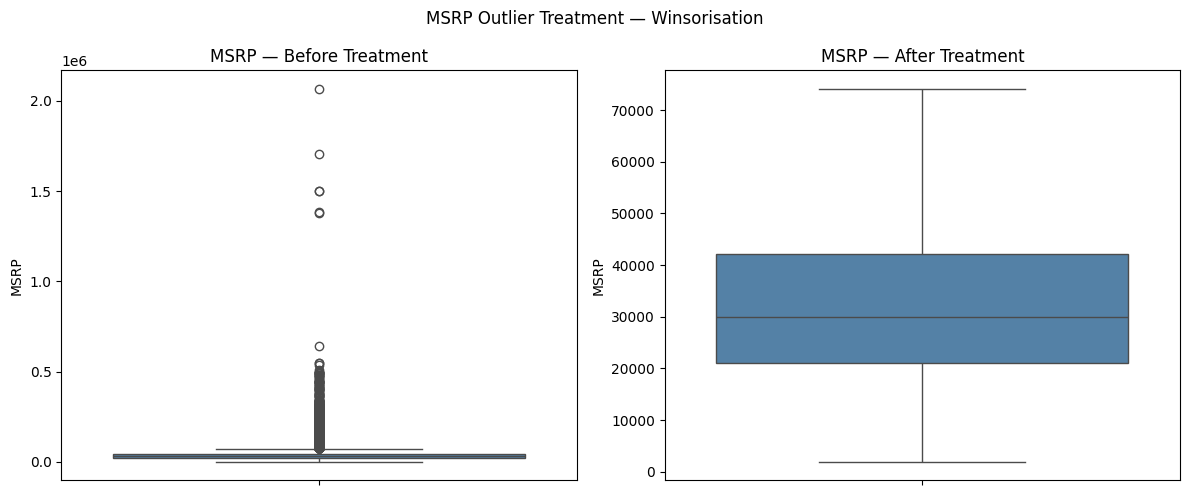


Engine HP — IQR: 130.00, Lower: -25.00, Upper: 495.00


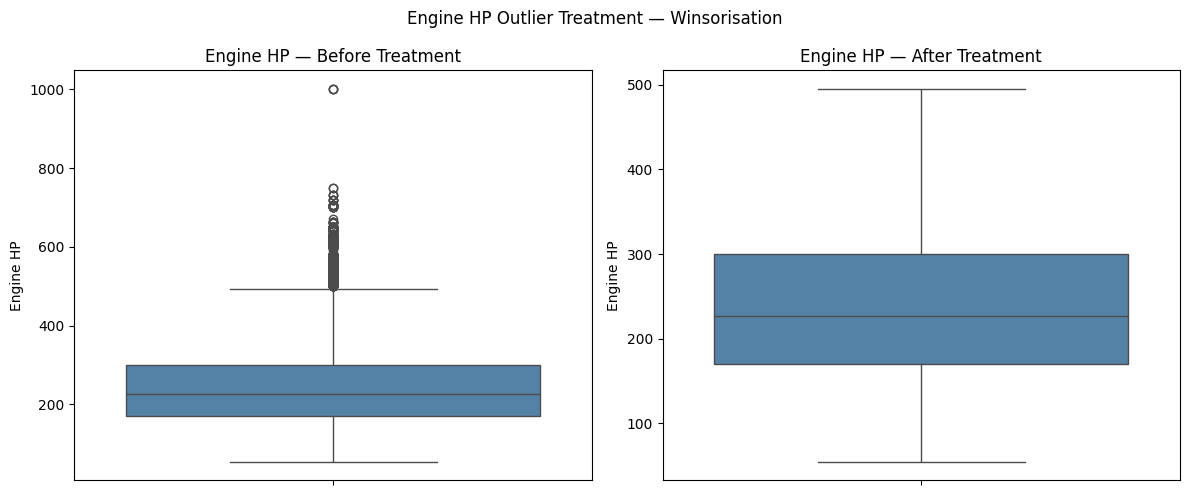


Popularity — IQR: 1460.00, Lower: -1641.00, Upper: 4199.00


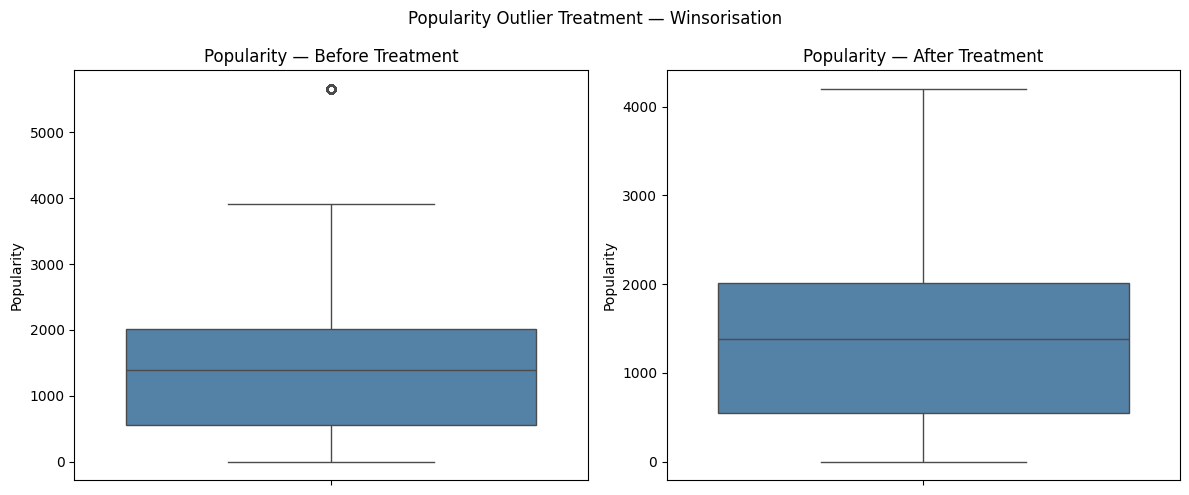


highway MPG — IQR: 8.00, Lower: 10.00, Upper: 42.00


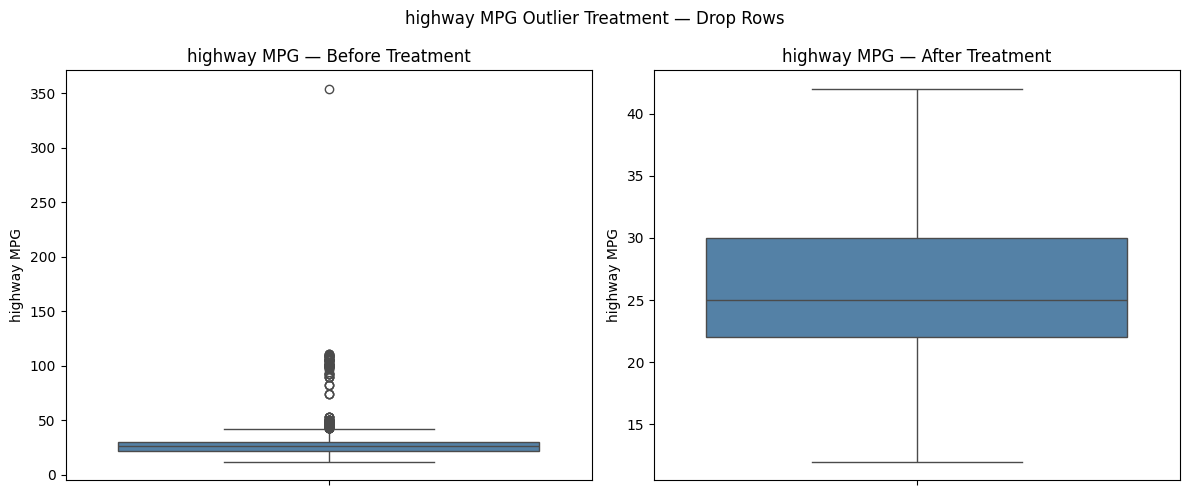


city mpg — IQR: 7.00, Lower: 4.50, Upper: 32.50


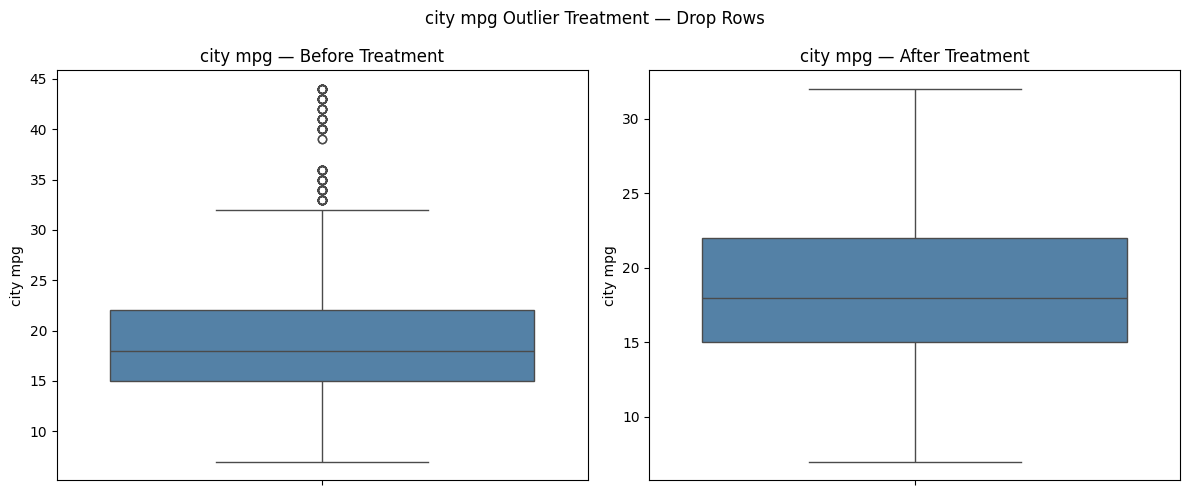


Engine Cylinders — Rows with 0: 0


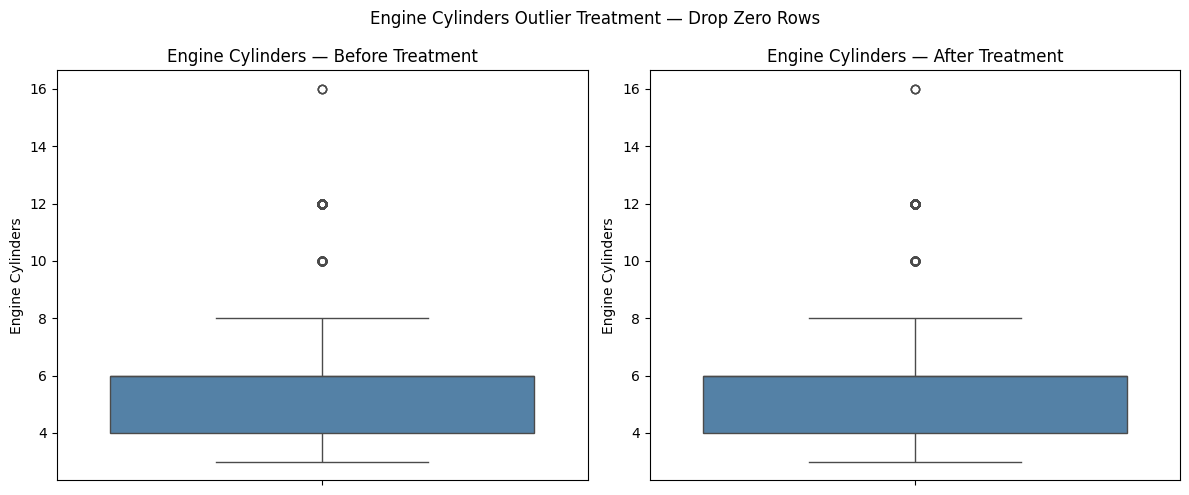


Year — IQR: 10.00, Lower: 1991.00, Upper: 2031.00


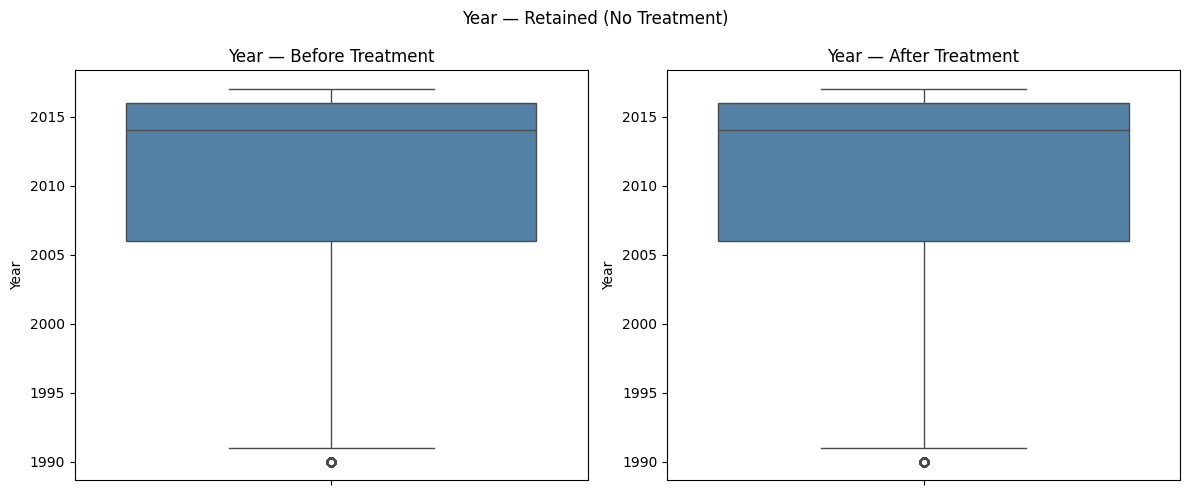


Number of Doors — IQR: 2.00, Lower: -1.00, Upper: 7.00


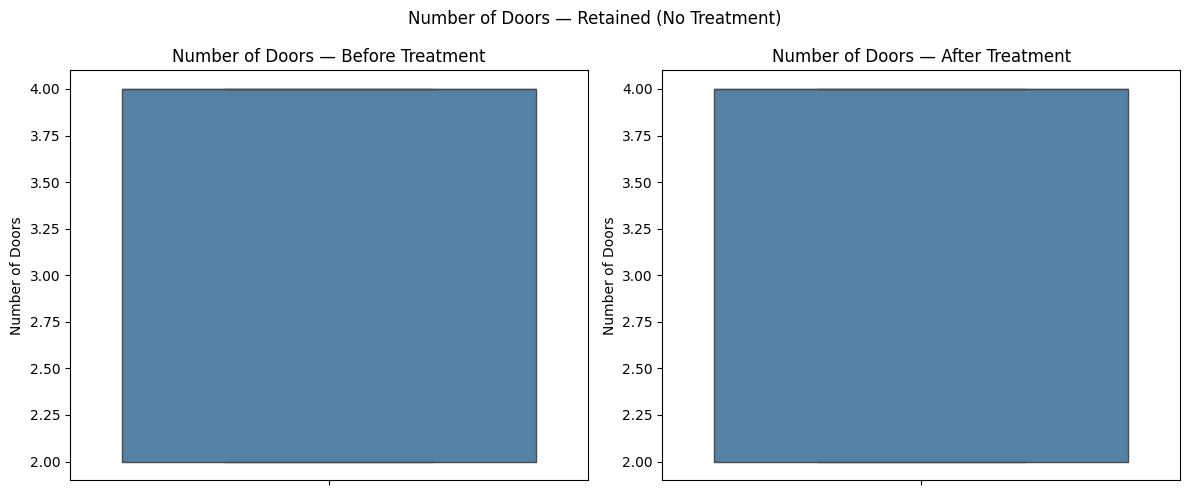


Total rows after outlier treatment: 11592
Rows removed: 322


In [14]:
# Define treatment for each column
outlier_treatment = {
    'MSRP'          : 'winsorise',
    'Engine HP'     : 'winsorise',
    'Popularity'    : 'winsorise',
    'highway MPG'   : 'drop',
    'city mpg'      : 'drop',
    'Engine Cylinders': 'drop_zero',
    'Year'          : 'retain',
    'Number of Doors': 'retain'
}

for col, treatment in outlier_treatment.items():

    # Calculate IQR for all except drop_zero
    if treatment != 'drop_zero':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        print(f"\n{col} — IQR: {IQR:.2f}, Lower: {lower:.2f}, Upper: {upper:.2f}")

    # Before treatment
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    col_original = df[col].copy()
    sns.boxplot(y=col_original, ax=axes[0], color='steelblue')
    axes[0].set_title(f"{col} — Before Treatment")
    axes[0].set_ylabel(col)

    # Apply treatment
    if treatment == 'winsorise':
        df[col] = df[col].clip(lower=lower, upper=upper)
        title = f"{col} Outlier Treatment — Winsorisation"

    elif treatment == 'drop':
        df = df[df[col] <= upper]
        title = f"{col} Outlier Treatment — Drop Rows"

    elif treatment == 'drop_zero':
        print(f"\n{col} — Rows with 0: {(df[col] == 0).sum()}")
        df = df[df[col] != 0]
        title = f"{col} Outlier Treatment — Drop Zero Rows"

    elif treatment == 'retain':
        title = f"{col} — Retained (No Treatment)"

    # After plot
    sns.boxplot(y=df[col], ax=axes[1], color='steelblue')
    axes[1].set_title(f"{col} — After Treatment")
    axes[1].set_ylabel(col)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

# Summary
print(f"\nTotal rows after outlier treatment: {len(df)}")
print(f"Rows removed: {11914 - len(df)}")

## Observations from Outlier Treatment

| Column | Treatment | Justification |
|---|---|---|
| MSRP | Winsorisation — capped at $74,078 | Physically real but extreme — exotic cars distort regression |
| Engine HP | Winsorisation — capped at 490 HP | Physically real but extreme — reduces model distortion |
| Popularity | Winsorisation — capped at 4,100 | Twitter metric — extreme values not meaningful |
| highway MPG | Drop rows — removed values > 42 MPG | Physically impossible for conventional cars |
| city mpg | Drop rows — removed values > 32 MPG | Physically impossible for conventional cars |
| Engine Cylinders | Drop rows — removed 0 cylinder rows | No combustion engine has 0 cylinders |
| Year | Retained | Old cars (1990) are physically valid |
| Number of Doors | Retained | Only 2/3/4 values — no real outliers |

## 3.3 Categorical Encoding

This cell converts all categorical columns into numerical format 
using three encoding strategies based on column characteristics.

### Encoding Strategy Table

| Column | Strategy | Reason |
|---|---|---|
| Transmission Type | One-hot (drop_first=True) | Nominal, 4 categories ≤ 8 |
| Driven_Wheels | One-hot (drop_first=True) | Nominal, 4 categories ≤ 8 |
| Vehicle Size | Ordinal (0/1/2) | Ordered: Compact < Midsize < Large |
| Make | Frequency encoding | Nominal, 48 categories > 8 |
| Engine Fuel Type | Frequency encoding | Nominal, 10 categories > 8 |
| Vehicle Style | Frequency encoding | Nominal, 16 categories > 8 |
| Model | Dropped | 915 unique values — ID column |
| Market Category | Dropped | 71 multi-label combinations |

In [15]:
#Transmission Type— One-Hot Encoding
df = pd.get_dummies(df, columns=['Transmission Type'], drop_first=True)
if 'Transmission Type_UNKNOWN' in df.columns:
    df = df.drop(columns=['Transmission Type_UNKNOWN']) # dropped because it was not meaningful

print([col for col in df.columns if 'Transmission' in col])

# Driven_Wheels — One-Hot Encoding
df = pd.get_dummies(df, columns=["Driven_Wheels"], drop_first=True)
print([col for col in df.columns if 'Driven_Wheels' in col])

# Vehicle Size — Ordinal Encoding
size_order = {'Compact': 0, 'Midsize': 1, 'Large': 2}
df['Vehicle Size'] = df['Vehicle Size'].map(size_order)

# Frequency Encoding
cols = ["Make", "Engine Fuel Type", "Vehicle Style"]

for col in cols:
    freq = df[col].value_counts()
    df[col] = df[col].map(freq)

# Drop Columns
df = df.drop(columns=['Model', 'Market Category'])
print(df.columns.tolist())
print(df.shape)
df

['Transmission Type_AUTOMATIC', 'Transmission Type_MANUAL']
['Driven_Wheels_four wheel drive', 'Driven_Wheels_front wheel drive', 'Driven_Wheels_rear wheel drive']
['Make', 'Year', 'Engine Fuel Type', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity', 'MSRP', 'Transmission Type_AUTOMATIC', 'Transmission Type_MANUAL', 'Driven_Wheels_four wheel drive', 'Driven_Wheels_front wheel drive', 'Driven_Wheels_rear wheel drive']
(11592, 17)


,Make,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Transmission Type_AUTOMATIC,Transmission Type_MANUAL,Driven_Wheels_four wheel drive,Driven_Wheels_front wheel drive,Driven_Wheels_rear wheel drive
0,327,2011,1999,335.0,6.0,2.0,0,1211,26,19,3916,46135.0,False,True,False,False,True
1,327,2011,1999,300.0,6.0,2.0,0,793,28,19,3916,40650.0,False,True,False,False,True
2,327,2011,1999,300.0,6.0,2.0,0,1211,28,20,3916,36350.0,False,True,False,False,True
3,327,2011,1999,230.0,6.0,2.0,0,1211,28,18,3916,29450.0,False,True,False,False,True
4,327,2011,1999,230.0,6.0,2.0,0,793,28,18,3916,34500.0,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,250,2012,1999,300.0,6.0,4.0,1,585,23,16,204,46120.0,True,False,False,False,False
11910,250,2012,1999,300.0,6.0,4.0,1,585,23,16,204,56670.0,True,False,False,False,False
11911,250,2012,1999,300.0,6.0,4.0,1,585,23,16,204,50620.0,True,False,False,False,False
11912,250,2013,1520,300.0,6.0,4.0,1,585,23,16,204,50920.0,True,False,False,False,False


## Observations from Categorical Encoding

All categorical columns have been successfully encoded into numerical 
format. One-hot encoding was applied to Transmission Type and 
Driven_Wheels creating 5 new binary columns. Vehicle Size was ordinally 
encoded preserving the natural size order (Compact=0, Midsize=1, Large=2). 
Make, Engine Fuel Type and Vehicle Style were frequency encoded replacing 
each category with its count. Model and Market Category were dropped due 
to extremely high cardinality. Final dataset has 17 columns and 11,592 rows.

## 3.4 Data Quality Report

This cell confirms the final state of the cleaned dataset — zero missing 
values, final shape, and summary statistics of all numerical columns.

In [16]:
# Final Shape
print(f"Final shape: {df.shape}")

# Assert zero missing values
assert df.isnull().sum().sum() == 0, "Missing values still exist!"
print("Zero missing values confirmed")

df.describe()

# Saving Cleaned CSV File
df.to_csv("cleaned_data.csv", index=False)

Final shape: (11592, 17)
Zero missing values confirmed


## Observations from Data Quality Report

### Summary of Changes Made in Phase 3

| Action | Details |
|---|---|
| **Original rows** | 11,914 |
| **Rows removed** | 322 (outlier treatment in Phase 3.2) |
| **Final rows** | 11,592 |
| **Original columns** | 16 |
| **Columns dropped** | 2 (Model, Market Category) |
| **New columns created** | 5 (one-hot encoded Transmission Type and Driven_Wheels) |
| **Final columns** | 17 |
| **Missing values** |  Zero confirmed via assert statement |

### Key Observations from df.describe()
- **Engine HP** range is now 55–495 HP — extreme 1001 HP values successfully capped
- **MSRP** range is now $2,000–$74,078 — extreme $2M values successfully capped
- **highway MPG** max is now 42 — physically impossible 354 MPG removed
- **city mpg** max is now 32 — physically impossible 137 MPG removed
- **Engine Cylinders** min is now 3 — zero cylinder rows successfully removed
- **Vehicle Size** shows 0/1/2 — ordinal encoding confirmed
- All 11,592 rows have complete data — no missing values remain

## 3.5 Train/Test Split

This cell splits the cleaned dataset into 80% training and 20% test sets.
Stratification ensures class proportions of Vehicle Size are preserved 
in both splits. All scalers and encoders will be fitted on training 
data only to prevent data leakage.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['MSRP', 'Vehicle Size'])
y_reg = df['MSRP']
y_cls = df['Vehicle Size']

# train_test_split randomly shuffles your data and splits into 80% train and 20% test
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_cls,
    test_size=0.2, random_state=42,
    stratify=y_cls
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (9273, 15) | Test: (2319, 15)


## Observations from Train/Test Split

| Set | Rows | Percentage |
|---|---|---|
| Training set | 9,273 | 80% |
| Test set | 2,319 | 20% |
| Total | 11,592 | 100% |

Stratification on Vehicle Size ensures that the class distribution 
(Compact/Midsize/Large) is preserved equally in both training and 
test sets — preventing biased evaluation of the classification model 
in Phase 7.

# Phase 4: Data Visualization & Storytelling

In [18]:
# Load cleaned dataset
df = pd.read_csv("cleaned_data.csv")
print(df.shape)

(11592, 17)


## 4.1 Distribution Dashboard

This cell creates a 2×3 grid of KDE-overlaid histograms for the 6 most 
informative numerical features. Each subplot title includes the feature 
name and skewness value (γ1) to immediately communicate distribution shape.

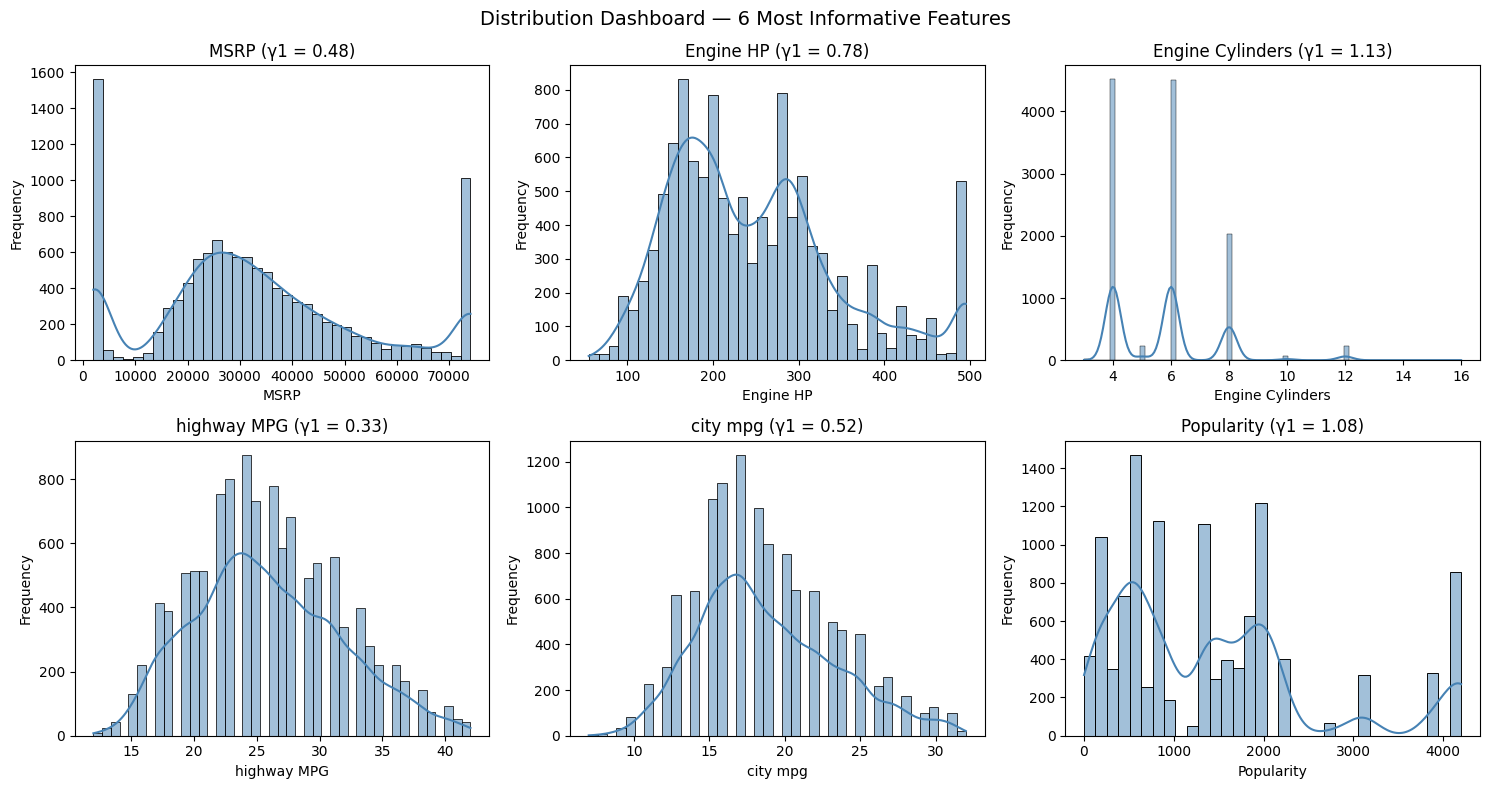

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten() # convert 2D to flatten for easy looping

features = ['MSRP', 'Engine HP', 'Engine Cylinders', 
            'highway MPG', 'city mpg', 'Popularity']

for i, feature in enumerate(features):
    
    skewness = stats.skew(df[feature])
    sns.histplot(df[feature], kde = True , ax=axes[i], color='steelblue')
    axes[i].set_title(f"{feature} (γ1 = {skewness:.2f})")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")
    
plt.suptitle("Distribution Dashboard — 6 Most Informative Features", fontsize=14)
plt.tight_layout()
plt.show()    
    


## Observations from Distribution Dashboard

| Feature | Skewness (γ1) | Shape | Interpretation |
|---|---|---|---|
| MSRP | 0.48 | Slight right skew | Most cars priced $20k–$40k. Spike at $74k due to Winsorisation cap |
| Engine HP | 0.78 | Right skewed | Most cars have 150–300 HP. Few high-performance cars pull tail right |
| Engine Cylinders | 1.13 | Right skewed | Discrete peaks at 4, 6 and 8 cylinders — standard engine configurations |
| highway MPG | 0.33 | Nearly symmetric | Well centered around 25 MPG after outlier removal |
| city mpg | 0.52 | Slight right skew | Centered around 17–18 MPG — typical city fuel consumption |
| Popularity | 1.08 | Right skewed | Few brands dominate Twitter mentions — most brands have low popularity |

**Key Takeaway:** Outlier treatment in Phase 3 significantly reduced skewness 
across all features — MSRP skewness dropped from 11.77 to 0.48, confirming 
that Winsorisation successfully reduced the influence of extreme values. 
Engine Cylinders shows discrete peaks at 4, 6 and 8 — reflecting standard 
automotive engine configurations rather than a continuous distribution.

## 4.2 Annotated Correlation Heatmap

This cell produces a full annotated Pearson correlation heatmap with 
upper triangle masked. The three strongest correlations are labelled 
directly on their cells using ax.annotate() for immediate visual clarity.

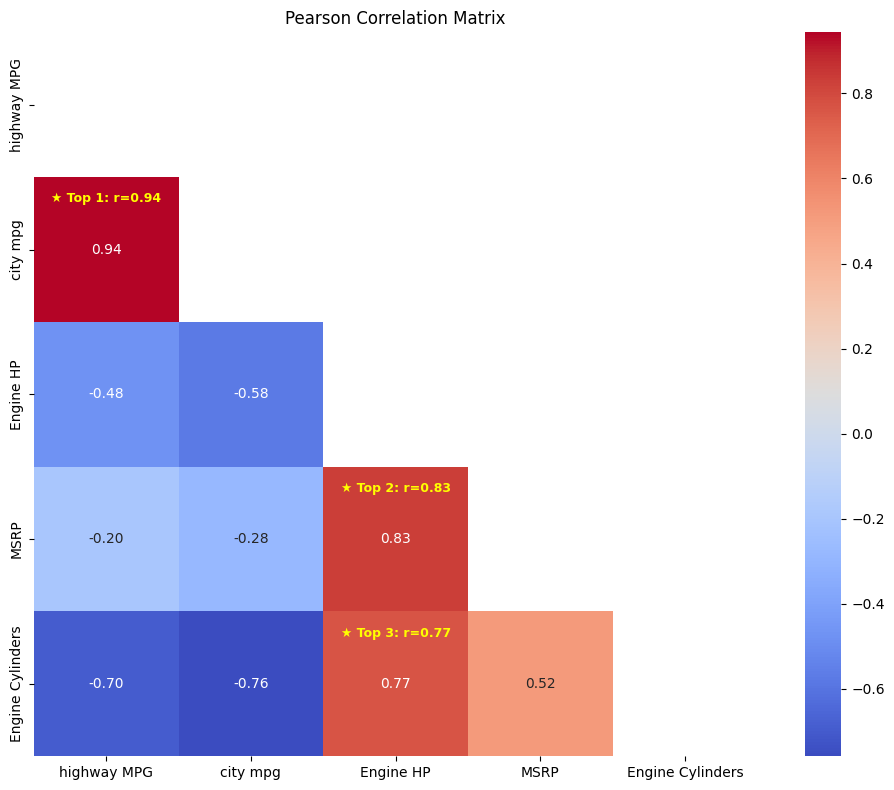

In [20]:
# Our Top 3 Strongest Correlations
# From Phase 2.3 heatmap:

# highway MPG vs city mpg → r = 0.89
# Engine HP vs MSRP → r = 0.66
# Engine HP vs Engine Cylinders → r = 0.78
features = ["highway MPG", "city mpg", "Engine HP", "MSRP", "Engine Cylinders"]
corr = df[features].corr()

mask = np.triu(np.ones_like(corr)) # Mask hides the upper triangle of the correlation matrix to avoid showing the same correlation value twice

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, 
            cmap="coolwarm", fmt=".2f", square=True, ax=ax)


# Annotate top 3 strongest correlations
ax.annotate("★ Top 1: r=0.94", xy=(0.5, 1.15), fontsize=9,
            color='yellow', ha='center', va='center', fontweight='bold')

ax.annotate("★ Top 2: r=0.83", xy=(2.5, 3.15), fontsize=9,
            color='yellow', ha='center', va='center', fontweight='bold')

ax.annotate("★ Top 3: r=0.77", xy=(2.5, 4.15), fontsize=9,
            color='yellow', ha='center', va='center', fontweight='bold')

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()


## Observations from Annotated Correlation Heatmap

The three strongest correlations identified are:

| Rank | Feature Pair | r value | Interpretation |
|---|---|---|---|
| ★ Top 1 | highway MPG vs city mpg | 0.94 | Near-perfect correlation — both measure fuel efficiency of same engine |
| ★ Top 2 | MSRP vs Engine HP | 0.83 | Strong positive — more powerful engines cost significantly more |
| ★ Top 3 | Engine Cylinders vs Engine HP | 0.77 | Strong positive — more cylinders produce more horsepower |

The near-perfect correlation between highway MPG and city mpg (r = 0.94) 
confirms severe multicollinearity — one of these features will be dropped 
during feature selection in Phase 5 to prevent unstable regression coefficients.

## 4.3 Target Analysis Plot

This cell produces two visualizations:
1. Scatter plot of the best predictor (Engine HP) vs regression target 
(MSRP) with fitted trend line and inset R² and RMSE statistics.
2. A 1×3 violin plot row showing the top 3 discriminating features 
(Engine HP, Engine Cylinders, highway MPG) split by Vehicle Size 
classification target.

R² = 0.697
RMSE = 10969.29


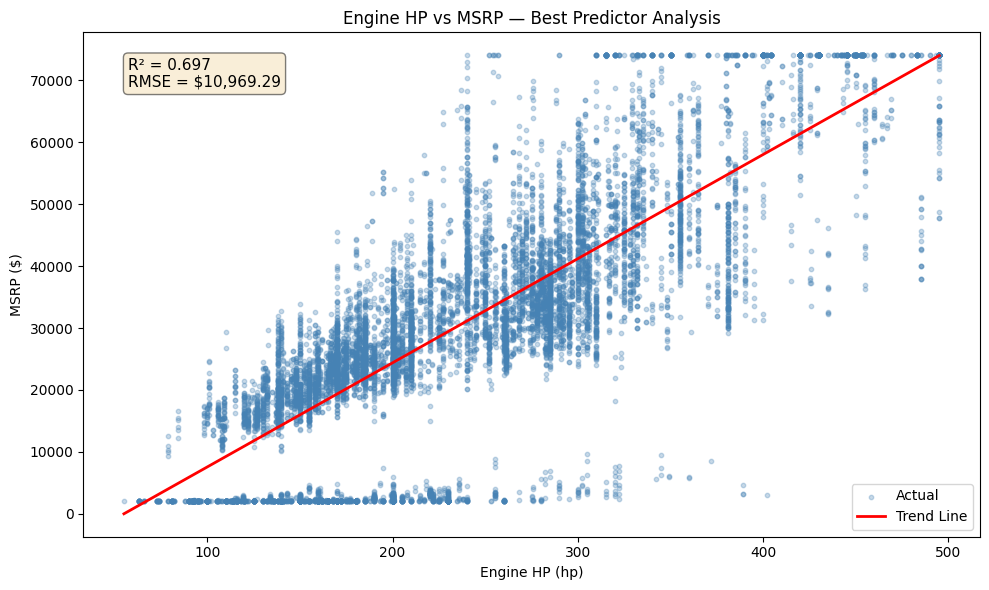

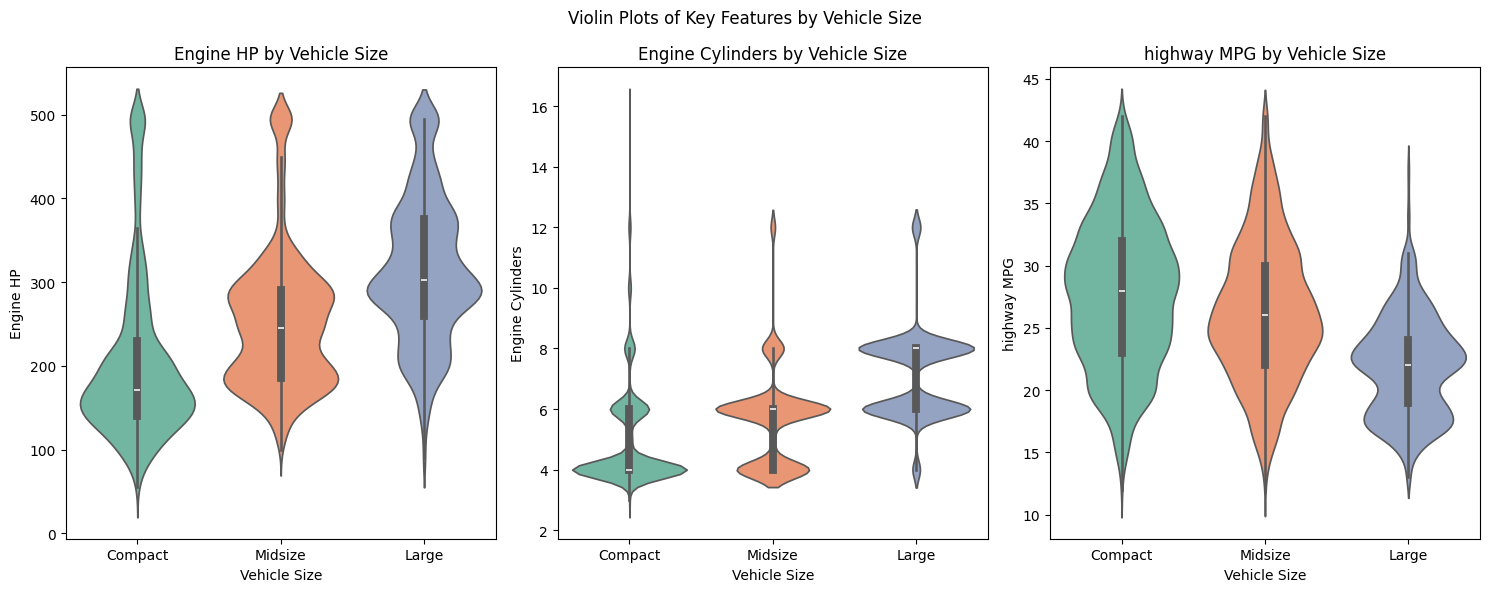

In [21]:
# R^2 measures how well our model explains variations in target variable.
# Range: 0 to 1

# R² = 1 → model perfectly predicts target
# R² = 0 → model explains nothing — same as predicting mean every time
# R² = 0.83 → model explains 83% of variation in MSRP

# RMSE (Root Mean Squared Error)
# What it is: Average error of your model's predictions in the same units as target.
# Lower RMSE = Better Model

from sklearn.metrics import r2_score, mean_squared_error

# Best Predictor
x = df["Engine HP"]
y = df["MSRP"]

coeffs = np.polyfit(x, y, deg=1) # finds best straight line through data, MSRP = m × Engine HP + c 
# Returns two numbers:
# coeffs[0] = slope (m) — how much MSRP increases per 1 HP
# coeffs[1] = intercept (c) — MSRP when HP = 0
trend = np.poly1d(coeffs) # creates trend function
y_predicted = trend(x) # generate all predictions

# Calculate R²
r2 = r2_score(y, y_predicted)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y, y_predicted))

print(f"R² = {r2:.3f}")
print(f"RMSE = {rmse:.2f}")

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(x, y, color='steelblue', alpha=0.3, s=10, label='Actual')

# Trend line
x_sorted = np.sort(x)
ax.plot(x_sorted, trend(x_sorted), color='red', linewidth=2, label='Trend Line')

# Inset text box
textstr = f"R² = {r2:.3f}\nRMSE = ${rmse:,.2f}"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', bbox=props)

ax.set_title("Engine HP vs MSRP — Best Predictor Analysis", fontsize=12)
ax.set_xlabel("Engine HP (hp)")
ax.set_ylabel("MSRP ($)")
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
top3_features = ['Engine HP', 'Engine Cylinders', 'highway MPG']

for i, feature in enumerate(top3_features):
        
        sns.violinplot(x='Vehicle Size', y=feature, 
               data=df, hue='Vehicle Size',
               palette='Set2', legend=False, ax=axes[i])
        
        axes[i].set_title(f"{feature} by Vehicle Size")
        axes[i].set_xlabel("Vehicle Size")
        axes[i].set_ylabel(f"{feature}")
        axes[i].set_xticks([0, 1, 2])                                    
        axes[i].set_xticklabels(['Compact', 'Midsize', 'Large'])         


plt.suptitle("Violin Plots of Key Features by Vehicle Size", fontsize=12)
plt.tight_layout()
plt.show()

## Observations from Target Analysis Plot

### Regression — Engine HP vs MSRP
Engine HP is the strongest single predictor of MSRP with R² = 0.697 
and RMSE = $10,969. This means Engine HP alone explains 69.7% of price 
variation — on average predictions are $10,969 off from actual price. 
The wide scatter around the trend line confirms that other features 
(brand, cylinders, year) also significantly influence MSRP. A much 
better R² is expected in Phase 6 when all features are used together.

### Classification — Violin Plots by Vehicle Size

| Feature | Separation | Observation |
|---|---|---|
| Engine HP | Strong | Clear shift from Compact (~175 HP) to Midsize (~245 HP) to Large (~300 HP) |
| Engine Cylinders | Strong | Compact concentrated at 4 cylinders, Large at 6-8 cylinders |
| highway MPG |  Moderate | Large cars (2) shifted lower ~18-26 MPG vs Compact ~22-32 MPG |

All three features show meaningful separation between Vehicle Size 
classes confirming they will be valuable features for the classification 
model in Phase 7.

## 4.4 Feature-Target Correlation Bar Chart

This cell computes Pearson correlation of every feature with MSRP 
and displays a horizontal bar chart sorted by absolute correlation 
value. Blue bars indicate positive correlation, red bars indicate 
negative correlation. A vertical line at x=0 separates positive 
from negative relationships.

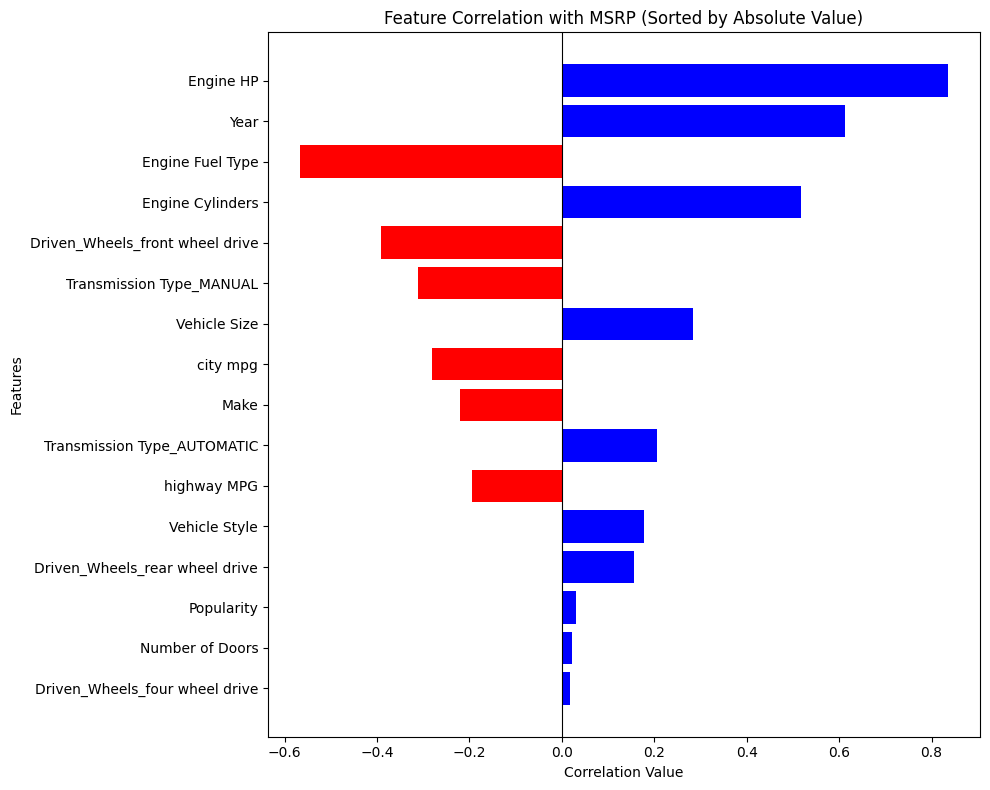

In [22]:
# Correlation of every feature with MSRP, except MSRP
correlations = df.drop(columns=['MSRP']).corrwith(df['MSRP'])

# Save original correlations for color distribtion
original_corr = correlations.copy()

# Sort by absolute value
sorted_correlations = correlations.abs().sort_values(ascending=True)

# Reindex to match sorted order
original_corr = original_corr[sorted_correlations.index]

# Assign colors
colors = ['blue' if corr> 0 else 'red' for corr in original_corr]

plt.figure(figsize=(10, 8))
plt.barh(sorted_correlations.index,    # y axis — feature names
         original_corr.values,  # bar lengths — correlation values
         color=colors)          # bar colors

plt.title("Feature Correlation with MSRP (Sorted by Absolute Value)", fontsize=12)
plt.xlabel("Correlation Value")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## Observations from Feature-Target Correlation Bar Chart

### Top Positive Correlations with MSRP
| Feature | Correlation | Interpretation |
|---|---|---|
| Engine HP | 0.83 | Strongest predictor — more powerful engines cost significantly more |
| Year | 0.61 | Newer models cost more — technology and features improve over time |
| Engine Cylinders | 0.52 | More cylinders → more power → higher price |

### Top Negative Correlations with MSRP
| Feature | Correlation | Interpretation |
|---|---|---|
| Engine Fuel Type | -0.54 | Regular unleaded cars are cheaper — premium/exotic fuel types cost more |
| Driven_Wheels_front wheel drive | -0.42 | Front wheel drive cars are economy vehicles — cheaper |
| Transmission Type_MANUAL | -0.38 | Manual transmission cars tend to be cheaper than automatic |

### Weak Correlations (near zero)
Popularity, Number of Doors and Driven_Wheels_four wheel drive show 
almost no relationship with MSRP — these features will likely be 
dropped or assigned low importance during feature selection in Phase 5.

### Key Takeaway
Engine HP remains the strongest single predictor of MSRP (r = 0.83). 
Interestingly Year shows a stronger correlation (0.61) than Engine 
Cylinders (0.52) — suggesting that newer cars command higher prices 
regardless of engine size, possibly due to technology improvements 
and inflation over the 1990-2017 period covered by this dataset.

## 4.5 Joint Density Plot

This cell produces a 2D hexbin plot of the two most correlated 
features (highway MPG vs city mpg, r = 0.94) with marginal 
histograms on both axes using plt.GridSpec() for custom layout. 
Darker hexagons indicate higher data density.

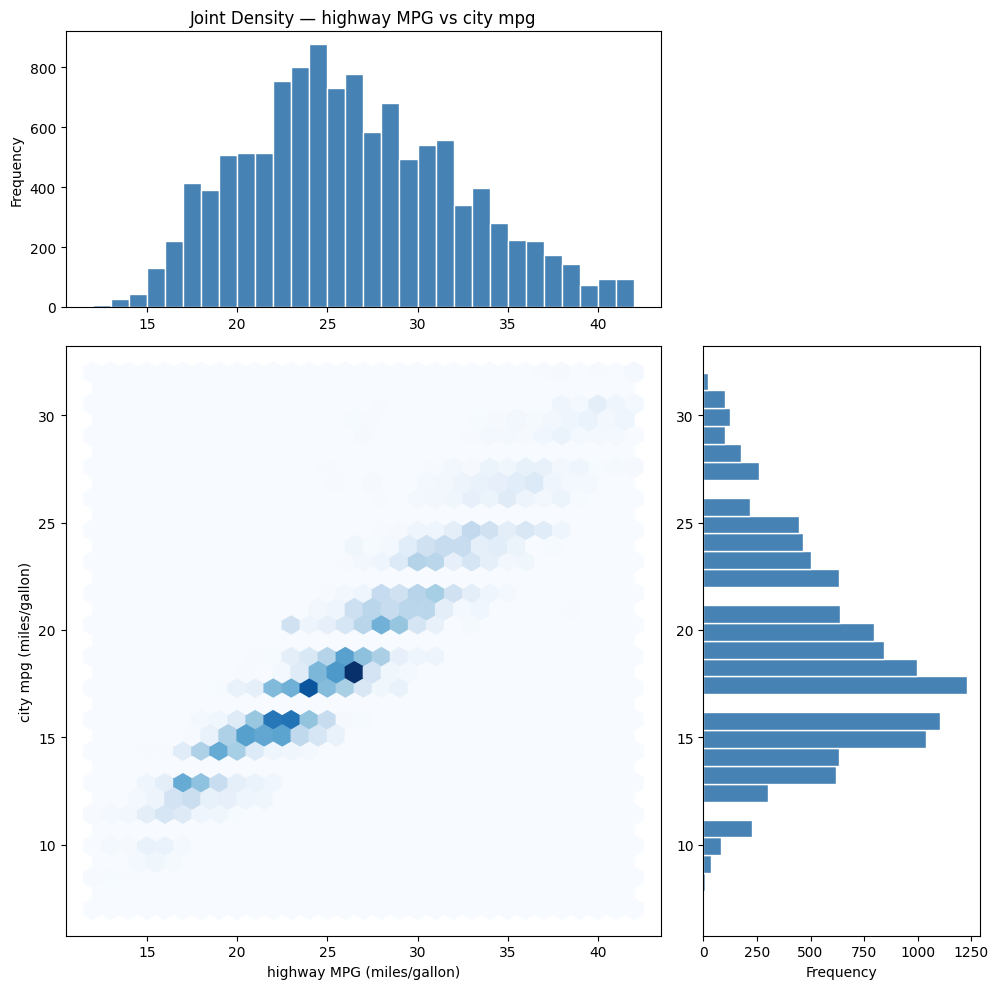

In [29]:
# What is a Joint Density Plot?
# It shows the relationship between two features simultaneously using:

# A 2D density plot in the center — shows where most data points are concentrated
# Marginal histograms on the sides — shows distribution of each feature individually

# Two most correlated features
x = df['highway MPG']
y = df['city mpg']

# Create grid layout
fig = plt.figure(figsize=(10, 10))
gs = plt.GridSpec(3, 3, figure=fig)  # 3x3 grid

ax_main = fig.add_subplot(gs[1:3, 0:2]) # main plot — takes 2x2 area
ax_top = fig.add_subplot(gs[0, 0:2])    # top histogram — takes 1x2 area
ax_right = fig.add_subplot(gs[1:3, 2])  # right histogram — takes 2x1 area

# Main plot — hexbin
ax_main.hexbin(x, y, gridsize=30, cmap='Blues')
ax_main.set_xlabel("highway MPG (miles/gallon)")
ax_main.set_ylabel("city mpg (miles/gallon)")

# Top histogram — highway MPG distribution
ax_top.hist(x, bins=30, color='steelblue', edgecolor='white')
ax_top.set_ylabel("Frequency")
ax_top.set_title("Joint Density — highway MPG vs city mpg")

# Right histogram — city mpg distribution
ax_right.hist(y, bins=30, color='steelblue', 
              edgecolor='white', orientation='horizontal')
ax_right.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

## Observations from Joint Density Plot

The hexbin plot confirms the near-perfect correlation (r = 0.94) 
between highway MPG and city mpg — the darkest hexagons cluster 
tightly along a diagonal band centered around highway MPG = 24–26 
and city mpg = 17–18, representing the most common fuel efficiency 
range for cars in this dataset.

The marginal histograms reveal that highway MPG peaks around 22–28 
MPG while city mpg peaks around 15–20 MPG — city fuel efficiency 
is consistently lower than highway efficiency for the same car, 
which is expected since city driving involves more stopping and 
starting that consumes more fuel.

The strong diagonal pattern and tight clustering confirm that these 
two features are nearly redundant — one will be dropped during 
feature selection in Phase 5 to eliminate multicollinearity.

## 4.6 Domain-Specific Insight Plot

This cell reveals a domain-specific insight by plotting average MSRP 
per model year from 1990 to 2017 using a line plot. This shows how 
automotive pricing has evolved over time in the dataset.

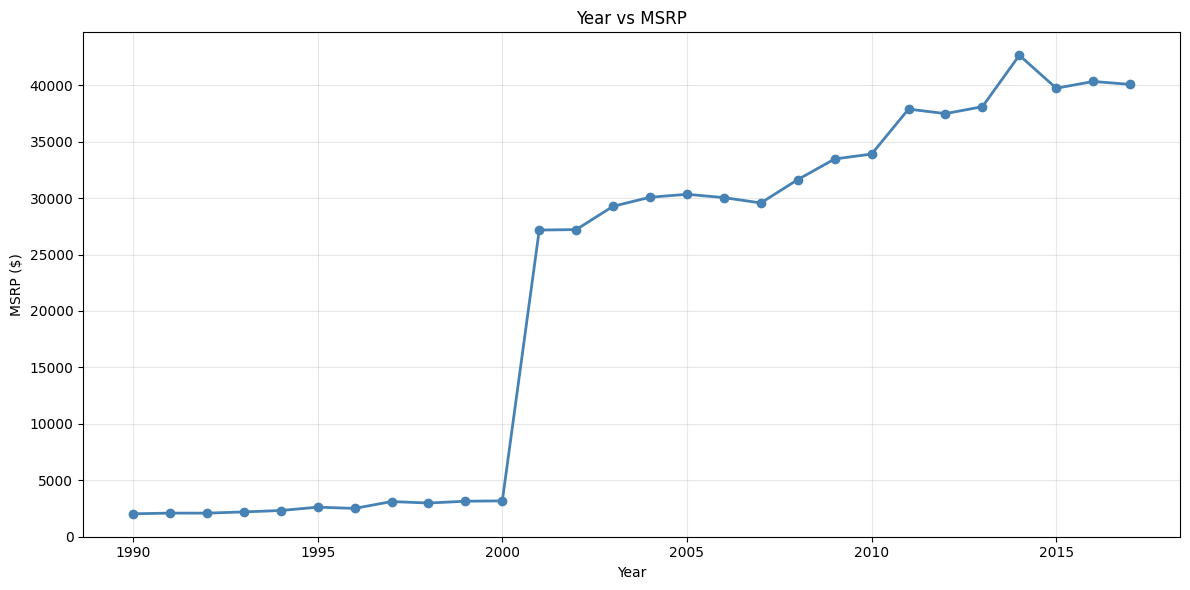

In [28]:
# Average MSRP by Year — Line Plot

avg_msrp_year = df.groupby('Year')['MSRP'].mean()

plt.figure(figsize=(12, 6))
plt.plot(avg_msrp_year.index, avg_msrp_year.values, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Year')
plt.ylabel('MSRP ($)')
plt.title('Year vs MSRP')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Observations from Domain-Specific Insight Plot

The line plot reveals a striking pattern in automotive pricing over 
the 1990–2017 period. Average MSRP remained artificially low at 
$2,000–$3,000 from 1990–2000 due to sparse representation of older 
models in the dataset — mostly budget economy cars survived into 
digital records from that era.

A dramatic jump occurs at 2001 where average MSRP rises sharply to 
~$27,000 — reflecting the dataset's much denser coverage of post-2000 
models including luxury and premium brands.

From 2001 to 2017 a steady upward trend is visible — average MSRP 
grew from $27,000 to approximately $40,000 — an increase of ~48% 
over 16 years. This is consistent with automotive industry inflation, 
improved technology, and the growing popularity of premium SUVs and 
crossovers in the US market during this period. The peak at 2014 
($42,000) likely reflects a particularly strong luxury vehicle lineup 
released that year.

This insight confirms that **Year is a meaningful predictor of MSRP** 
(r = 0.61 from Phase 4.4) — newer cars genuinely cost more on average.